
===== TaiESM1 =====


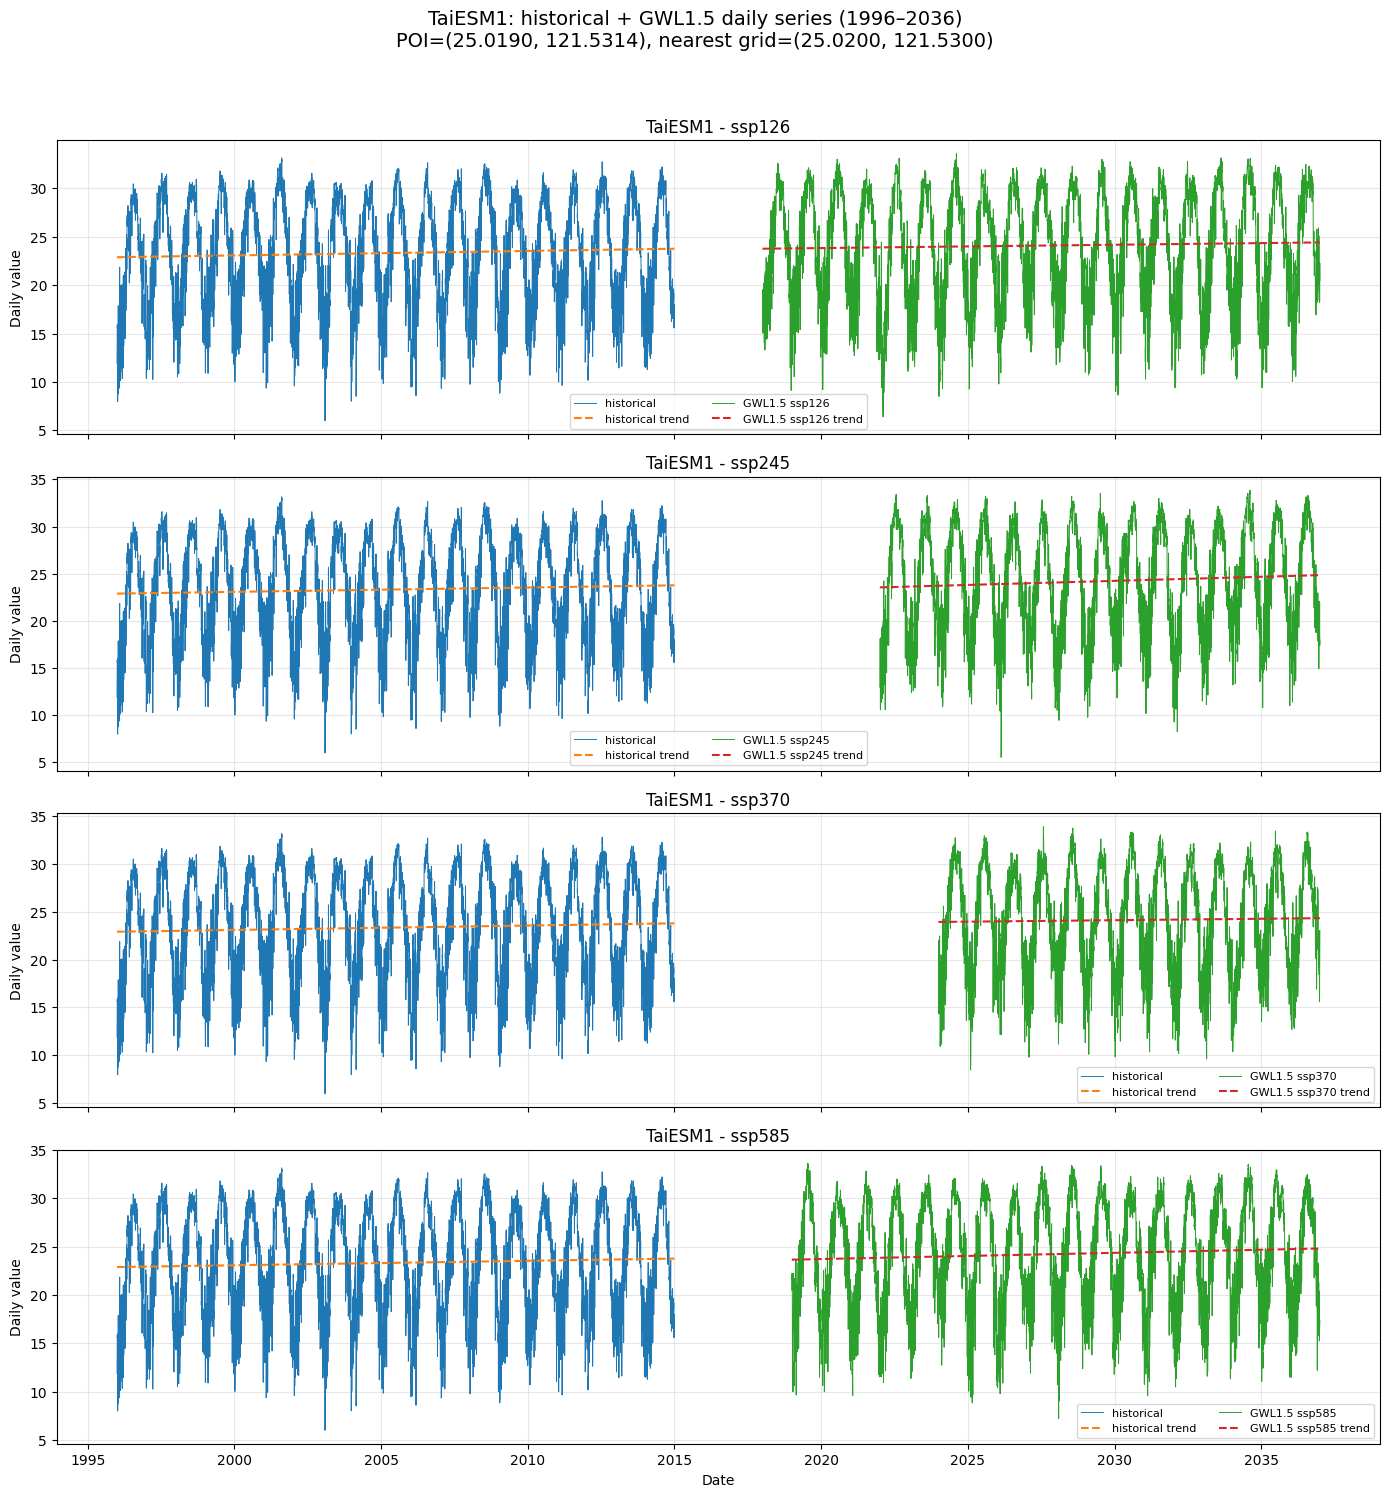

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/figures_GWL1p5_daily_1996_2036/TaiESM1_historical_GWL1p5_daily_1996_2036.png

===== ACCESS-CM2 =====


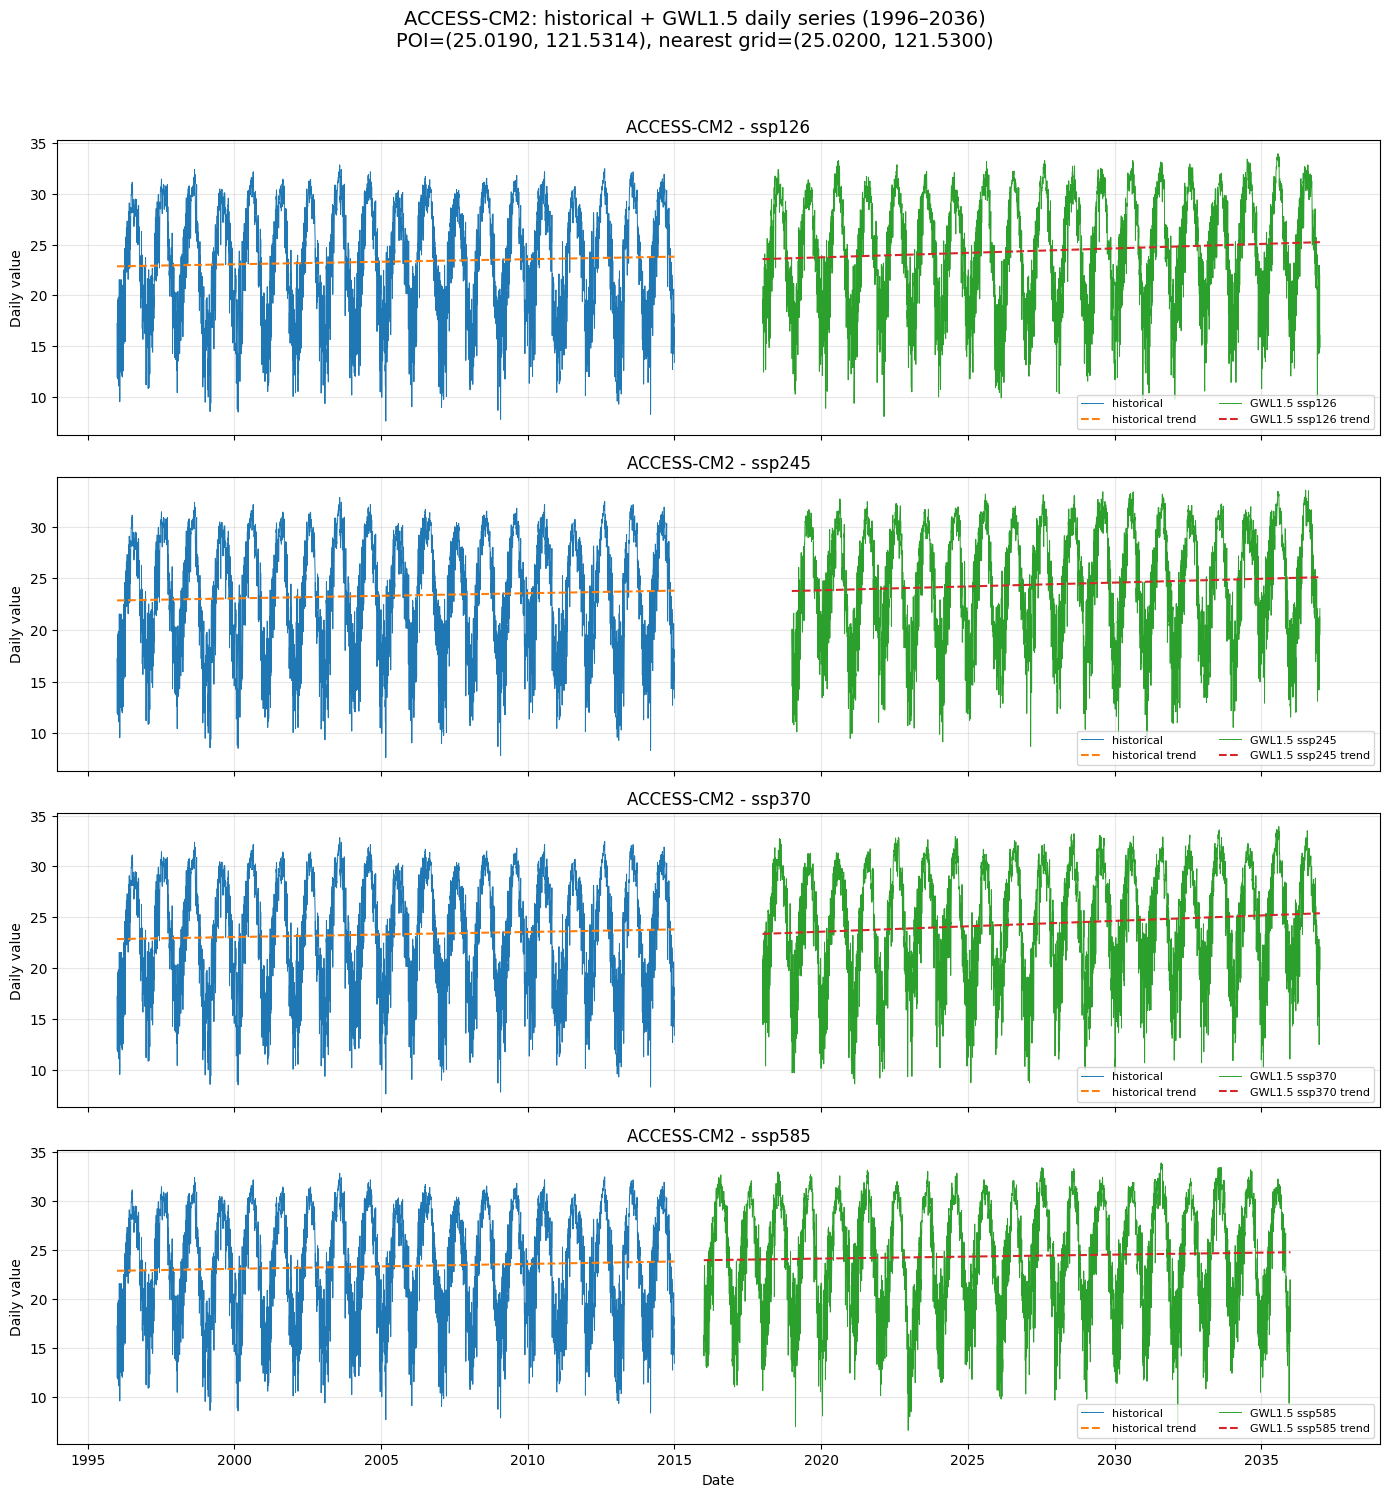

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/figures_GWL1p5_daily_1996_2036/ACCESS-CM2_historical_GWL1p5_daily_1996_2036.png

===== EC-Earth3 =====


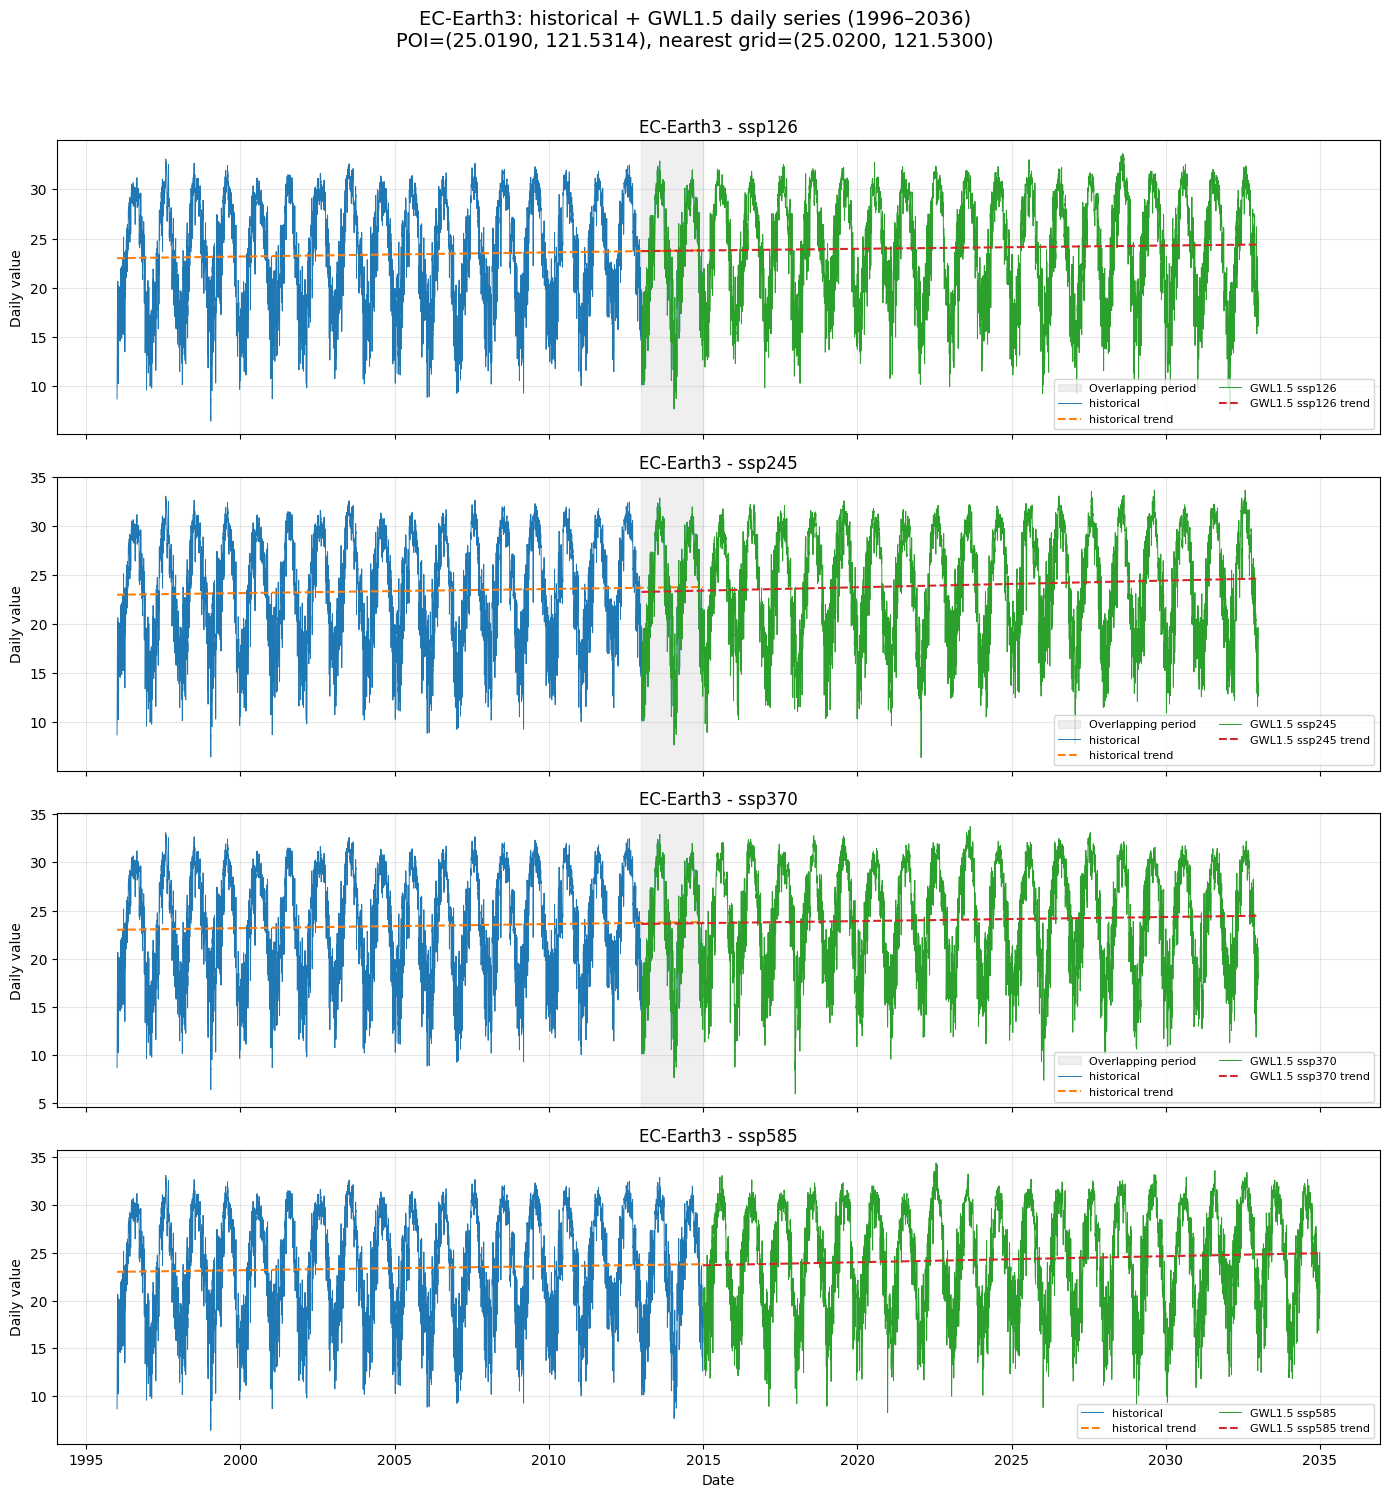

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/figures_GWL1p5_daily_1996_2036/EC-Earth3_historical_GWL1p5_daily_1996_2036.png


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# 1. 基本設定
# =========================
base_dir = Path("/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫")   # <<< 改這裡
models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]

historical_folder = "historical"
gwl_folder = "GWL1.5"

start_year = 1996
end_year = 2036
start_date = pd.Timestamp(f"{start_year}-01-01")
end_date   = pd.Timestamp(f"{end_year}-12-31")

poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

save_dir = base_dir / "figures_GWL1p5_daily_1996_2036"
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 工具函式
# =========================
def extract_year(file_path):
    return int(file_path.stem.split("_")[-1])

def find_files(folder_name, model_name, ssp_name=None, start_year=1996, end_year=2036):
    """
    精準抓檔：
    historical: ..._historical_MODEL_YEAR.csv
    GWL1.5:     ..._ssp245_MODEL_YEAR.csv
    """
    folder_path = base_dir / folder_name
    matched = []

    for f in folder_path.glob("*.csv"):
        parts = f.stem.split("_")
        if len(parts) < 3:
            continue

        year_part = parts[-1]
        model_part = parts[-2]
        scenario_part = parts[-3]

        if not year_part.isdigit():
            continue

        year = int(year_part)
        if year < start_year or year > end_year:
            continue

        if model_part != model_name:
            continue

        if folder_name == historical_folder:
            if scenario_part != "historical":
                continue
        else:
            if scenario_part != ssp_name:
                continue

        matched.append(f)

    matched = sorted(matched, key=extract_year)
    return matched

def find_matching_col(columns, keywords):
    for c in columns:
        cl = str(c).lower()
        for kw in keywords:
            if kw in cl:
                return c
    return None

def guess_lat_lon_cols(df):
    cols = df.columns.tolist()
    lat_col = find_matching_col(cols, ["lat", "latitude", "緯度"])
    lon_col = find_matching_col(cols, ["lon", "longitude", "lng", "經度"])
    return lat_col, lon_col

def detect_date_columns(df):
    """
    偵測像 20130101 這種日期欄名
    """
    date_cols = []
    for c in df.columns:
        c_str = str(c).strip()
        if c_str.isdigit() and len(c_str) == 8:
            date_cols.append(c)
    return date_cols

def select_nearest_grid_row(df, lat_col, lon_col, poi_lat, poi_lon):
    """
    選離 POI 最近的那一列格點
    """
    tmp = df.copy()
    tmp[lat_col] = pd.to_numeric(tmp[lat_col], errors="coerce")
    tmp[lon_col] = pd.to_numeric(tmp[lon_col], errors="coerce")

    tmp = tmp.dropna(subset=[lat_col, lon_col]).copy()
    if len(tmp) == 0:
        return None, None, None

    dist = np.sqrt((tmp[lat_col] - poi_lat)**2 + (tmp[lon_col] - poi_lon)**2)
    nearest_idx = dist.idxmin()

    nearest_lat = tmp.loc[nearest_idx, lat_col]
    nearest_lon = tmp.loc[nearest_idx, lon_col]

    row = tmp.loc[[nearest_idx]].copy()
    return row, nearest_lat, nearest_lon

def read_file(file_path, poi_lat, poi_lon):
    """
    讀單一 CSV：
    原始格式通常為
    LON, LAT, 20130101, 20130102, ...
    先選最近格點，再轉成 long format:
    date, value
    """
    df = pd.read_csv(file_path).copy()

    lat_col, lon_col = guess_lat_lon_cols(df)
    if lat_col is None or lon_col is None:
        raise ValueError(f"找不到經緯度欄位：{file_path.name}")

    date_cols = detect_date_columns(df)
    if len(date_cols) == 0:
        raise ValueError(f"找不到 YYYYMMDD 日期欄位：{file_path.name}")

    row_df, nearest_lat, nearest_lon = select_nearest_grid_row(
        df, lat_col, lon_col, poi_lat, poi_lon
    )
    if row_df is None:
        raise ValueError(f"無法找到最近格點：{file_path.name}")

    long_df = row_df.melt(
        id_vars=[lon_col, lat_col],
        value_vars=date_cols,
        var_name="date",
        value_name="value"
    )

    long_df["date"] = pd.to_datetime(long_df["date"], format="%Y%m%d", errors="coerce")
    long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")

    long_df = long_df.dropna(subset=["date", "value"]).copy()
    long_df = long_df.sort_values("date").reset_index(drop=True)

    # 附加資訊
    long_df.attrs["nearest_lat"] = nearest_lat
    long_df.attrs["nearest_lon"] = nearest_lon

    return long_df[["date", "value"]]

def build_series(folder_name, model_name, ssp_name=None):
    files = find_files(
        folder_name=folder_name,
        model_name=model_name,
        ssp_name=ssp_name,
        start_year=start_year,
        end_year=end_year
    )

    if len(files) == 0:
        return None

    dfs = []
    nearest_lat = None
    nearest_lon = None

    for f in files:
        try:
            df = read_file(f, poi_lat, poi_lon)
            if len(df) > 0:
                dfs.append(df)
                if nearest_lat is None:
                    nearest_lat = df.attrs.get("nearest_lat", None)
                    nearest_lon = df.attrs.get("nearest_lon", None)
        except Exception as e:
            print(f"⚠️ 跳過 {f.name}: {e}")

    if len(dfs) == 0:
        return None

    out = pd.concat(dfs, ignore_index=True)
    out = out.drop_duplicates(subset=["date"]).sort_values("date").reset_index(drop=True)
    out = out[(out["date"] >= start_date) & (out["date"] <= end_date)].copy()

    if len(out) == 0:
        return None

    out.attrs["nearest_lat"] = nearest_lat
    out.attrs["nearest_lon"] = nearest_lon
    return out

def fit_trend(df):
    """
    直接對日資料做線性趨勢
    """
    if df is None or len(df) < 2:
        return None, None, None

    tmp = df.dropna(subset=["date", "value"]).copy()
    if len(tmp) < 2:
        return None, None, None

    x = mdates.date2num(tmp["date"])
    y = tmp["value"].values

    slope, intercept = np.polyfit(x, y, 1)
    trend = slope * x + intercept

    trend_df = pd.DataFrame({
        "date": tmp["date"].values,
        "trend": trend
    })
    return slope, intercept, trend_df

def get_overlap_segments_from_dates(dates1, dates2):
    """
    找兩組日期的重疊連續區段
    """
    if dates1 is None or dates2 is None:
        return []

    s1 = set(pd.to_datetime(dates1).dt.normalize())
    s2 = set(pd.to_datetime(dates2).dt.normalize())

    overlap = sorted(s1.intersection(s2))
    if len(overlap) == 0:
        return []

    segments = []
    start = overlap[0]
    prev = overlap[0]

    for d in overlap[1:]:
        if d == prev + pd.Timedelta(days=1):
            prev = d
        else:
            segments.append((start, prev))
            start = d
            prev = d

    segments.append((start, prev))
    return segments

# =========================
# 3. 主繪圖
# =========================
for model in models:
    print(f"\n===== {model} =====")

    hist_df = build_series(historical_folder, model_name=model, ssp_name=None)

    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 15), sharex=True)

    nearest_lat_used = None
    nearest_lon_used = None

    for ax, ssp in zip(axes, ssps):
        gwl_df = build_series(gwl_folder, model_name=model, ssp_name=ssp)

        # 重疊區上色：historical vs 該 SSP 的 GWL1.5
        if hist_df is not None and gwl_df is not None:
            overlap_segments = get_overlap_segments_from_dates(hist_df["date"], gwl_df["date"])
            for i, (seg_start, seg_end) in enumerate(overlap_segments):
                ax.axvspan(
                    seg_start,
                    seg_end + pd.Timedelta(days=1),
                    alpha=0.12,
                    color="gray",
                    label="Overlapping period" if i == 0 else None
                )

        # historical
        if hist_df is not None:
            ax.plot(
                hist_df["date"], hist_df["value"],
                linewidth=0.7, label="historical"
            )
            slope_h, intercept_h, trend_h = fit_trend(hist_df)
            if trend_h is not None:
                ax.plot(
                    trend_h["date"], trend_h["trend"],
                    linestyle="--", linewidth=1.5,
                    label="historical trend"
                )

            if nearest_lat_used is None:
                nearest_lat_used = hist_df.attrs.get("nearest_lat", None)
                nearest_lon_used = hist_df.attrs.get("nearest_lon", None)

        # GWL1.5 + SSP
        if gwl_df is not None:
            ax.plot(
                gwl_df["date"], gwl_df["value"],
                linewidth=0.7, label=f"GWL1.5 {ssp}"
            )
            slope_g, intercept_g, trend_g = fit_trend(gwl_df)
            if trend_g is not None:
                ax.plot(
                    trend_g["date"], trend_g["trend"],
                    linestyle="--", linewidth=1.5,
                    label=f"GWL1.5 {ssp} trend"
                )

            if nearest_lat_used is None:
                nearest_lat_used = gwl_df.attrs.get("nearest_lat", None)
                nearest_lon_used = gwl_df.attrs.get("nearest_lon", None)

        ax.set_ylabel("Daily value")
        ax.set_title(f"{model} - {ssp}")
        ax.grid(True, alpha=0.3)

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(handles, labels, fontsize=8, ncol=2, loc="best")
        else:
            ax.text(
                0.5, 0.5, "No data",
                transform=ax.transAxes,
                ha="center", va="center",
                fontsize=10, color="gray"
            )

    axes[-1].set_xlabel("Date")
    axes[-1].xaxis.set_major_locator(mdates.YearLocator(base=5))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    if nearest_lat_used is not None and nearest_lon_used is not None:
        fig.suptitle(
            f"{model}: historical + GWL1.5 daily series ({start_year}–{end_year})\n"
            f"POI=({poi_lat:.4f}, {poi_lon:.4f}), nearest grid=({nearest_lat_used:.4f}, {nearest_lon_used:.4f})",
            fontsize=14, y=0.995
        )
    else:
        fig.suptitle(
            f"{model}: historical + GWL1.5 daily series ({start_year}–{end_year})\n"
            f"POI=({poi_lat:.4f}, {poi_lon:.4f})",
            fontsize=14, y=0.995
        )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    out_path = save_dir / f"{model}_historical_GWL1p5_daily_{start_year}_{end_year}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✅ Saved: {out_path}")

Processing ACCESS-CM2 - ssp245


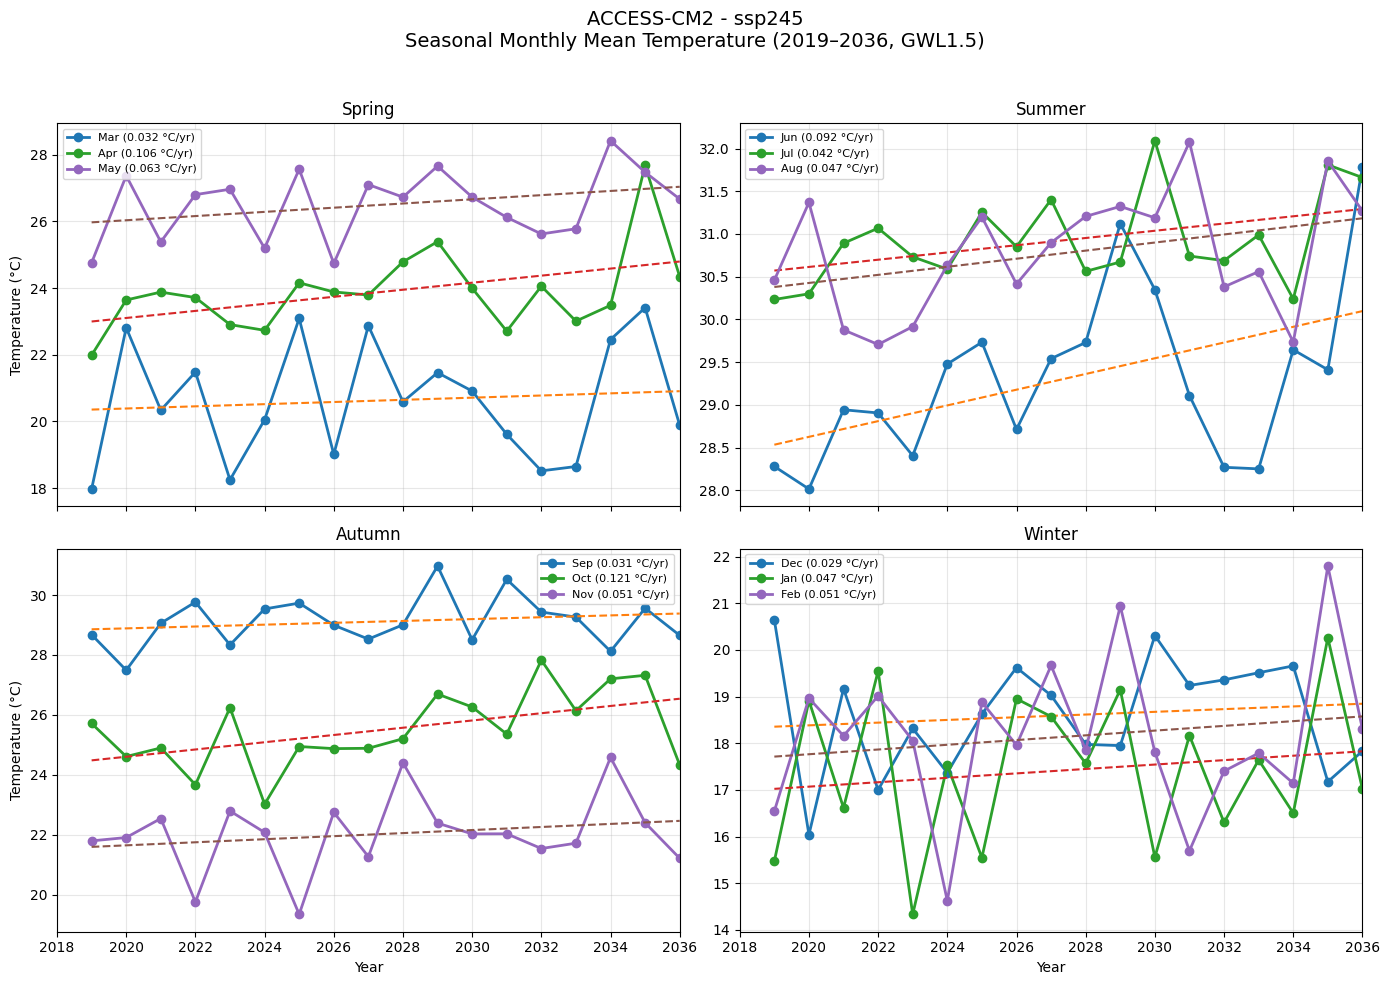

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_ACCESS_CM2_seasonal/ACCESS-CM2_ssp245_seasonal.png
Processing ACCESS-CM2 - ssp370


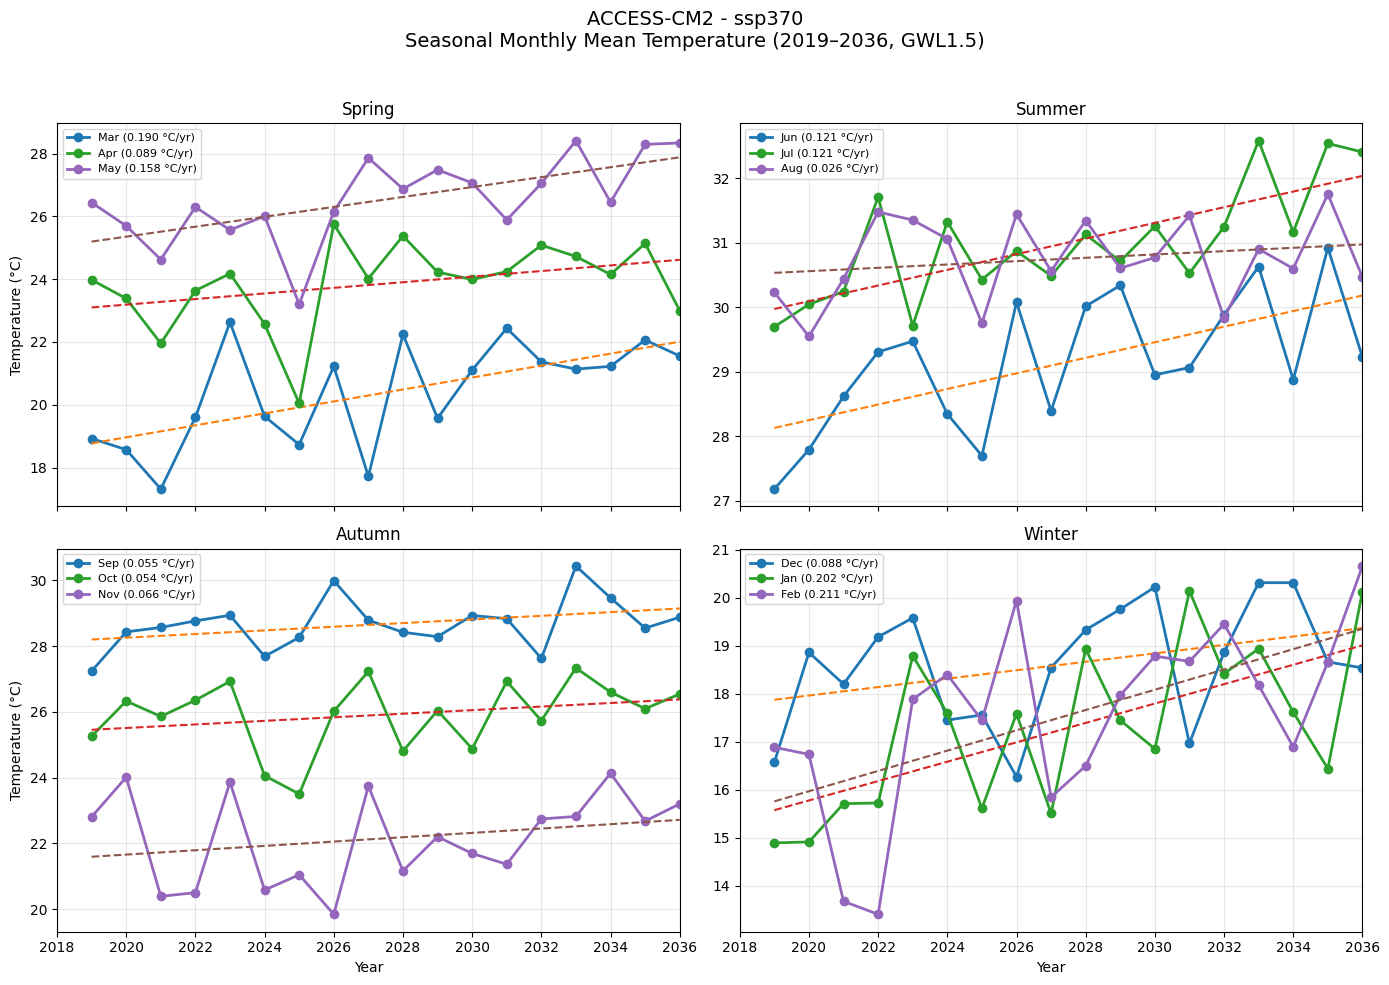

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_ACCESS_CM2_seasonal/ACCESS-CM2_ssp370_seasonal.png
Processing ACCESS-CM2 - ssp585


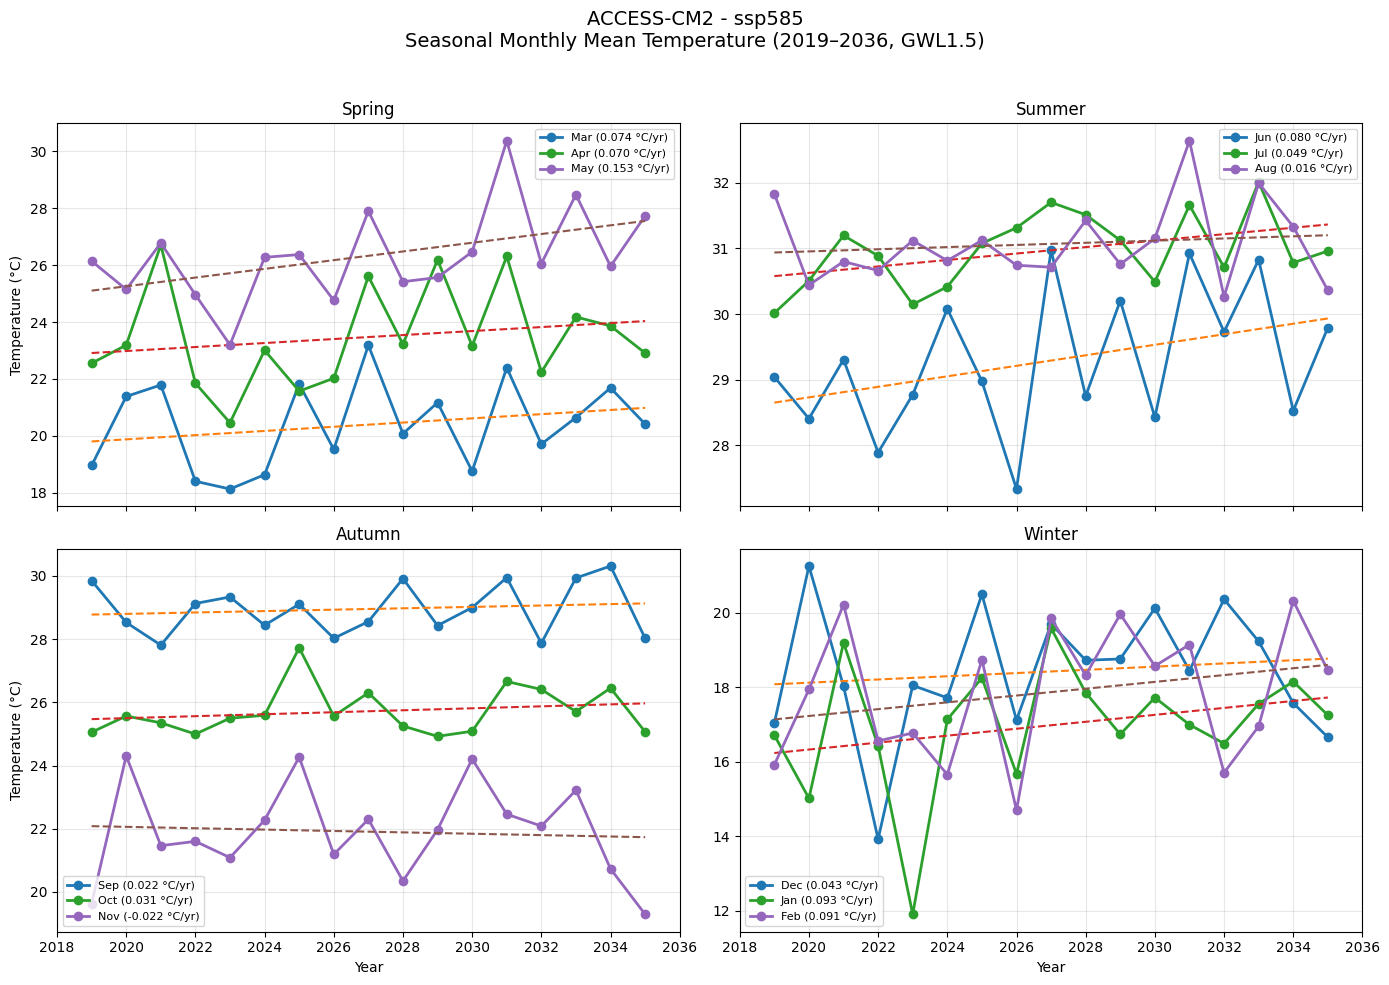

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_ACCESS_CM2_seasonal/ACCESS-CM2_ssp585_seasonal.png


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 設定
# =========================
model = "ACCESS-CM2"
ssps = ["ssp245", "ssp370", "ssp585"]

start_year = 2019
end_year = 2036

season_def = {
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
    "Winter": [12, 1, 2]
}

month_labels = {
    1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
    7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}

save_dir = base_dir / "final_ACCESS_CM2_seasonal"
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 日 → 月平均
# =========================
def daily_to_monthly(df):
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    monthly = (
        df.groupby(["year","month"])["value"]
        .mean()
        .reset_index()
    )

    monthly = monthly[
        (monthly["year"] >= start_year) &
        (monthly["year"] <= end_year)
    ]

    return monthly

# =========================
# 主程式
# =========================
for ssp in ssps:

    print(f"Processing {model} - {ssp}")

    df = build_series("GWL1.5", model, ssp)

    if df is None or len(df) == 0:
        print("⚠️ No data")
        continue

    monthly = daily_to_monthly(df)

    if len(monthly) == 0:
        print("⚠️ No monthly data")
        continue

    # ===== 畫圖 =====
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    axes = axes.flatten()

    for ax, (season, months) in zip(axes, season_def.items()):

        has_data = False

        for m in months:
            sub = monthly[monthly["month"] == m].copy()

            if len(sub) < 2:
                continue

            x = sub["year"].values
            y = sub["value"].values

            # ===== 趨勢 =====
            slope, intercept = np.polyfit(x, y, 1)
            trend = slope * x + intercept

            # ===== label（含趨勢）=====
            label = f"{month_labels[m]} ({slope:.3f} °C/yr)"

            # 原始線
            ax.plot(x, y, marker="o", linewidth=2, label=label)

            # 趨勢線
            ax.plot(x, trend, linestyle="--", linewidth=1.5)

            has_data = True

        ax.set_title(season, fontsize=12)
        ax.grid(alpha=0.3)

        if has_data:
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, "No data",
                    transform=ax.transAxes,
                    ha="center", va="center",
                    color="gray")

    # ===== 整體設定 =====
    axes[2].set_xlabel("Year")
    axes[3].set_xlabel("Year")
    axes[0].set_ylabel("Temperature (°C)")
    axes[2].set_ylabel("Temperature (°C)")
    axes[2].set_xlim([2018,2036])


    fig.suptitle(
        f"{model} - {ssp}\nSeasonal Monthly Mean Temperature (2019–2036, GWL1.5)",
        fontsize=14
    )

    plt.tight_layout(rect=[0,0,1,0.96])

    out_path = save_dir / f"{model}_{ssp}_seasonal.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"✅ Saved: {out_path}")

Processing EC-Earth3 - ssp245


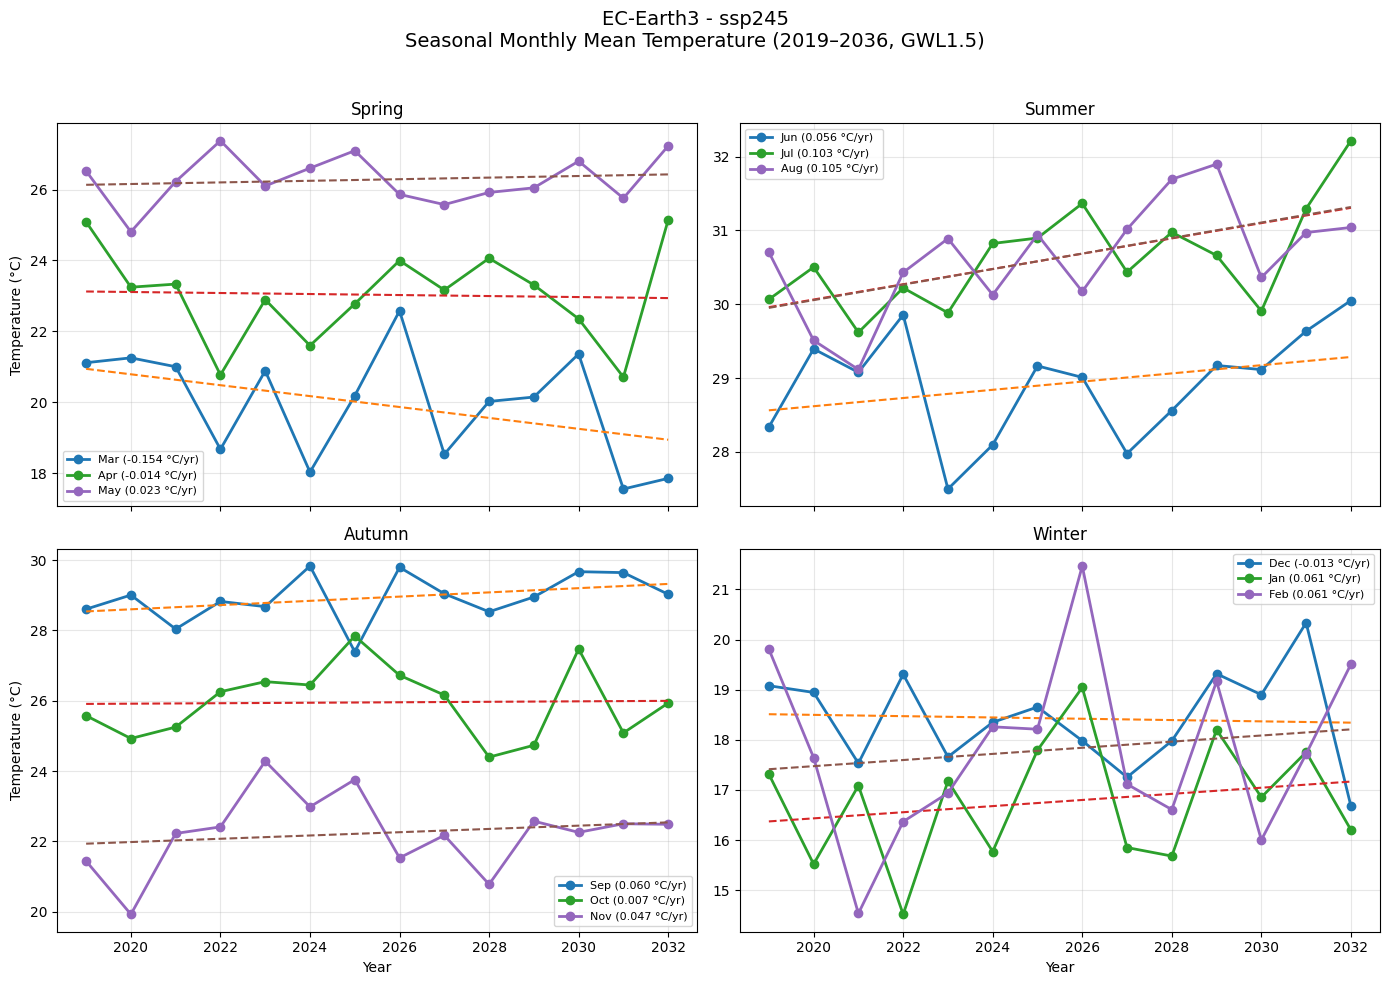

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_EC_Earth3_seasonal/EC-Earth3_ssp245_seasonal.png
Processing EC-Earth3 - ssp370


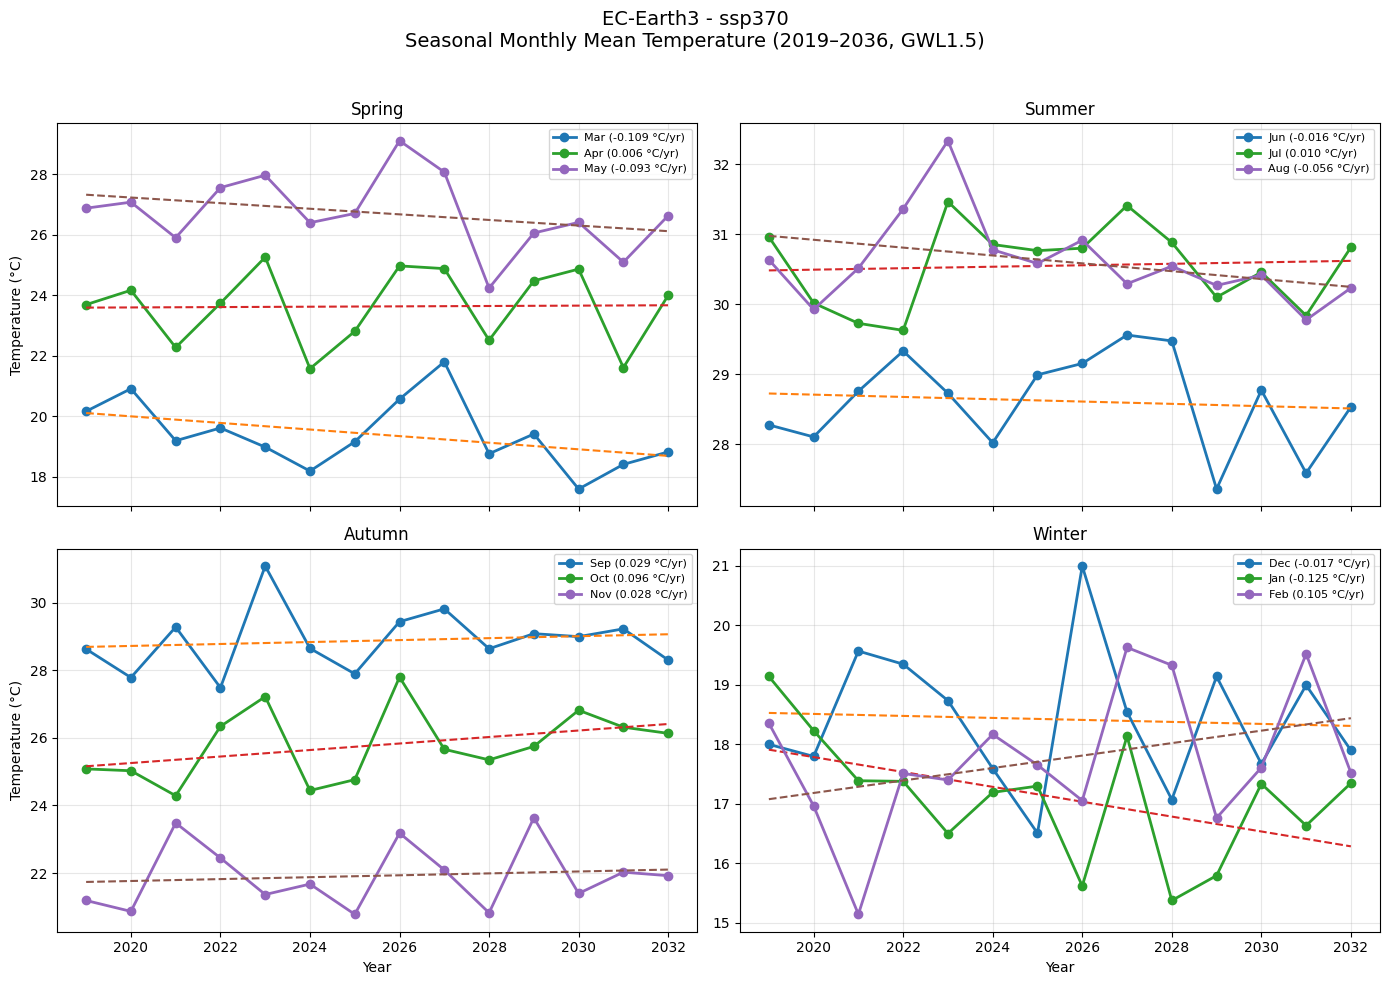

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_EC_Earth3_seasonal/EC-Earth3_ssp370_seasonal.png
Processing EC-Earth3 - ssp585


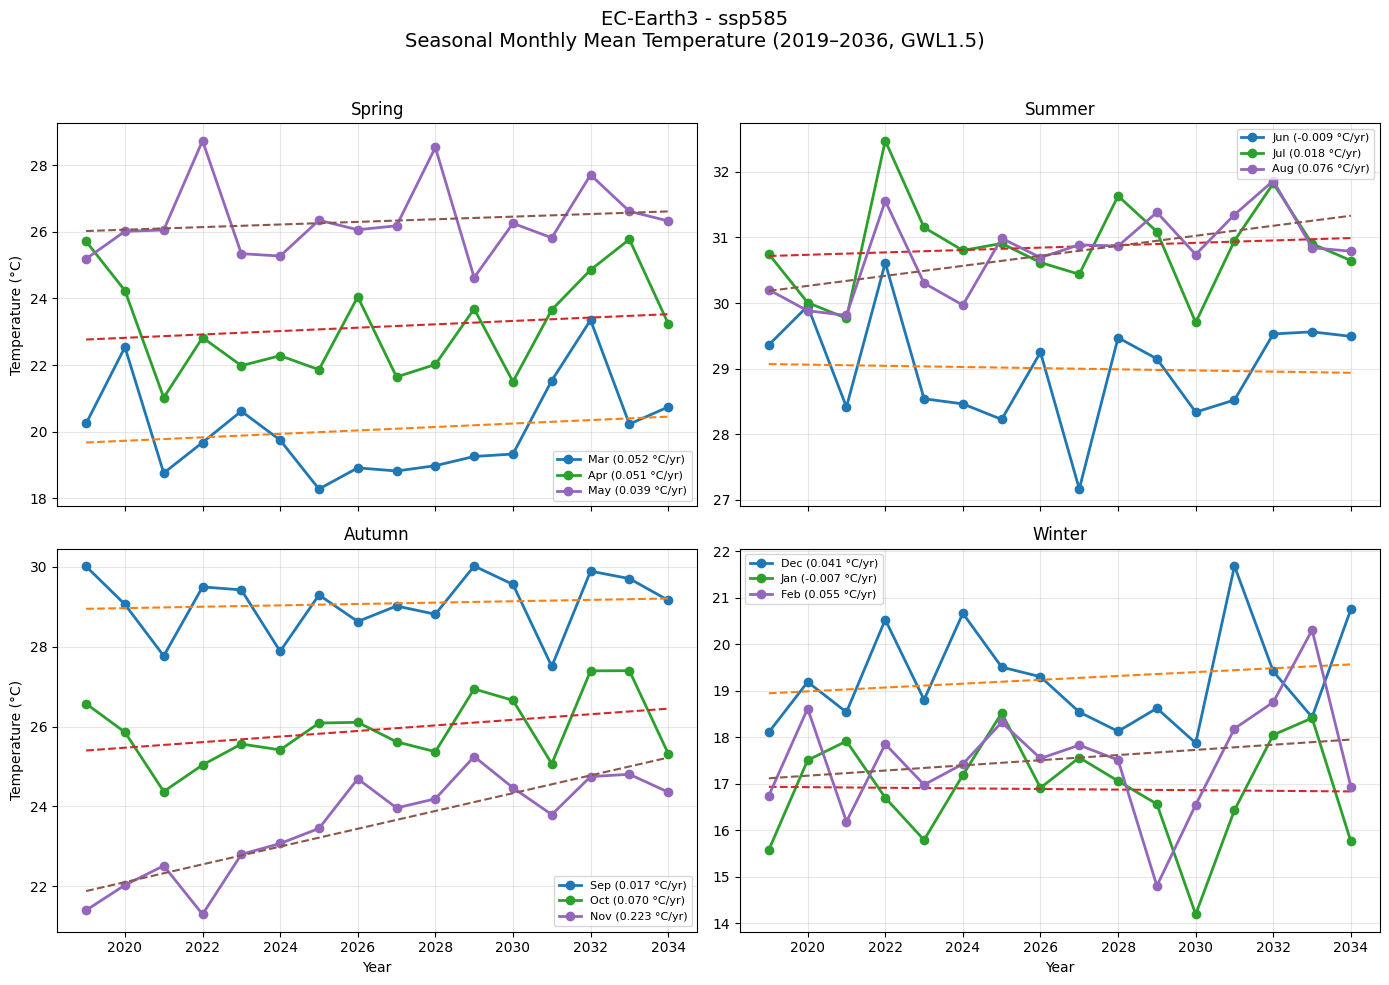

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_EC_Earth3_seasonal/EC-Earth3_ssp585_seasonal.png


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 設定
# =========================
model = "EC-Earth3"
ssps = ["ssp245", "ssp370", "ssp585"]

start_year = 2019
end_year = 2036

season_def = {
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
    "Winter": [12, 1, 2]
}

month_labels = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
    7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}

save_dir = base_dir / "final_EC_Earth3_seasonal"
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 日資料 → 月平均
# =========================
def daily_to_monthly(df):
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    monthly = (
        df.groupby(["year", "month"])["value"]
        .mean()
        .reset_index()
    )

    monthly = monthly[
        (monthly["year"] >= start_year) &
        (monthly["year"] <= end_year)
    ].copy()

    return monthly

# =========================
# 主程式
# =========================
for ssp in ssps:

    print(f"Processing {model} - {ssp}")

    df = build_series("GWL1.5", model, ssp)

    if df is None or len(df) == 0:
        print(f"⚠️ {model} - {ssp}: No data")
        continue

    monthly = daily_to_monthly(df)

    if monthly is None or len(monthly) == 0:
        print(f"⚠️ {model} - {ssp}: No monthly data")
        continue

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    axes = axes.flatten()

    for ax, (season, months) in zip(axes, season_def.items()):
        has_data = False

        for m in months:
            sub = monthly[monthly["month"] == m].copy()

            if len(sub) < 2:
                continue

            x = sub["year"].values
            y = sub["value"].values

            slope, intercept = np.polyfit(x, y, 1)
            trend = slope * x + intercept

            label = f"{month_labels[m]} ({slope:.3f} °C/yr)"

            ax.plot(
                x, y,
                marker="o",
                linewidth=2,
                label=label
            )

            ax.plot(
                x, trend,
                linestyle="--",
                linewidth=1.5
            )

            has_data = True

        ax.set_title(season, fontsize=12)
        ax.grid(alpha=0.3)

        if has_data:
            ax.legend(fontsize=8)
        else:
            ax.text(
                0.5, 0.5, "No data",
                transform=ax.transAxes,
                ha="center", va="center",
                color="gray"
            )

    axes[2].set_xlabel("Year")
    axes[3].set_xlabel("Year")
    axes[0].set_ylabel("Temperature (°C)")
    axes[2].set_ylabel("Temperature (°C)")

    fig.suptitle(
        f"{model} - {ssp}\nSeasonal Monthly Mean Temperature (2019–2036, GWL1.5)",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    out_path = save_dir / f"{model}_{ssp}_seasonal.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"✅ Saved: {out_path}")

Processing TaiESM1 - ssp245


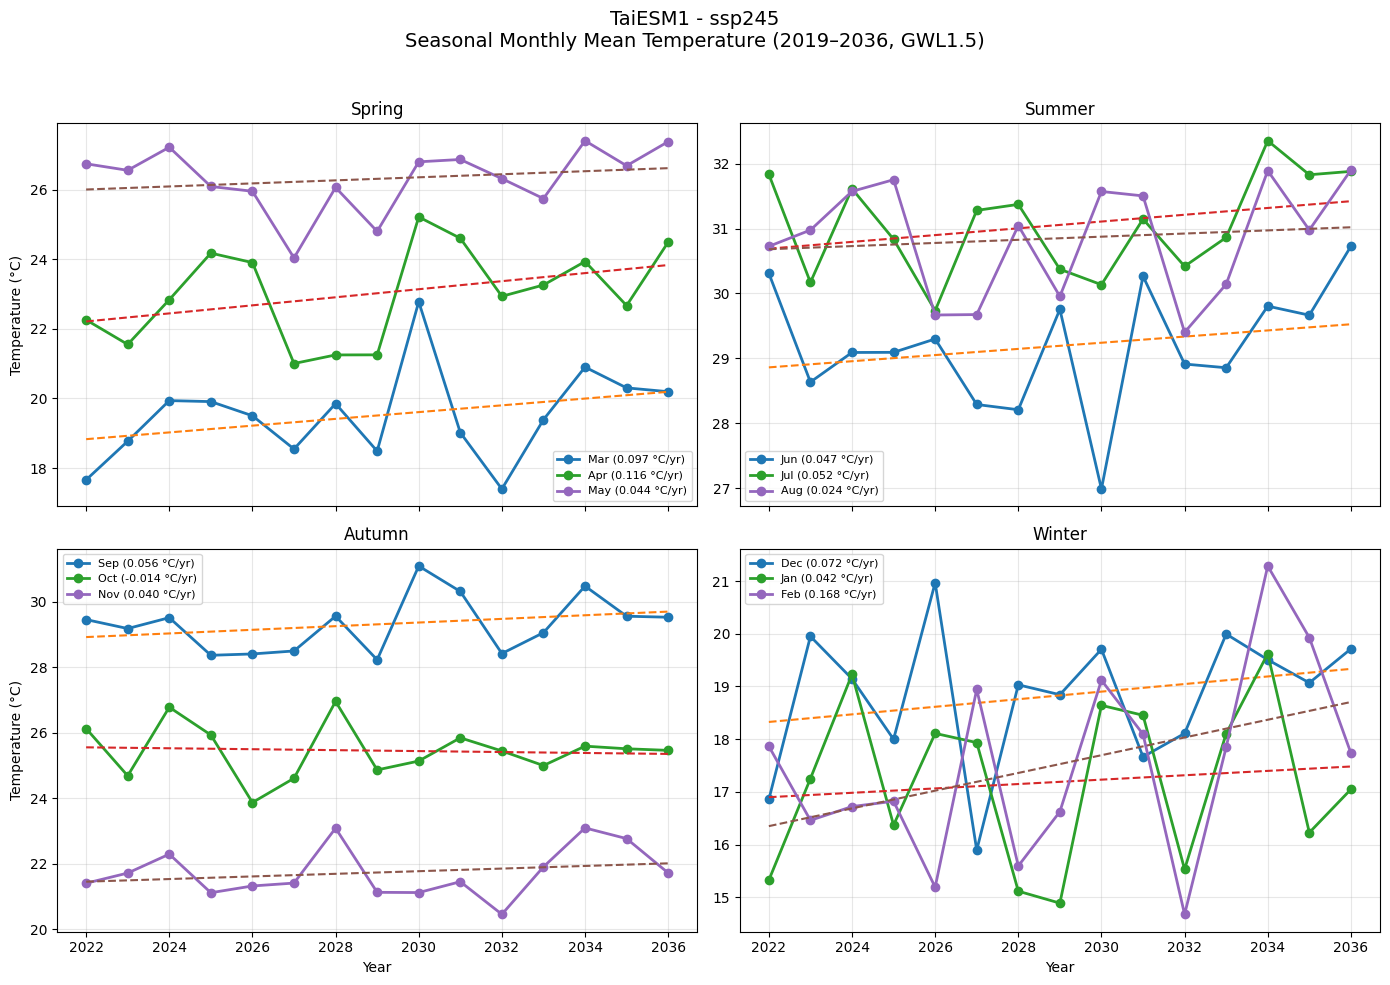

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_TaiESM1_seasonal/TaiESM1_ssp245_seasonal.png
Processing TaiESM1 - ssp370


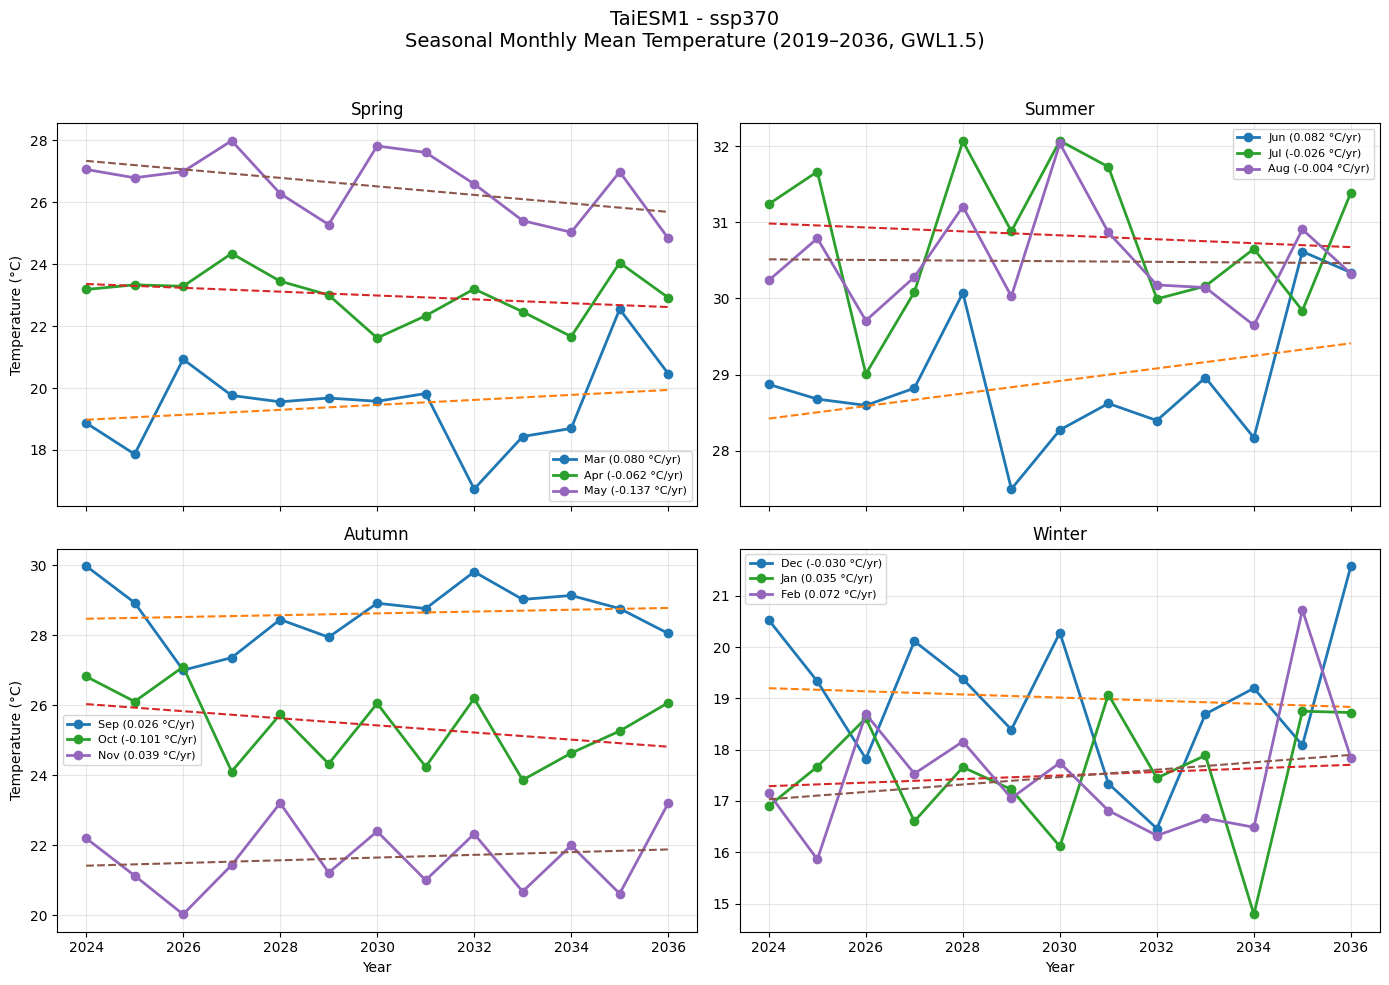

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_TaiESM1_seasonal/TaiESM1_ssp370_seasonal.png
Processing TaiESM1 - ssp585


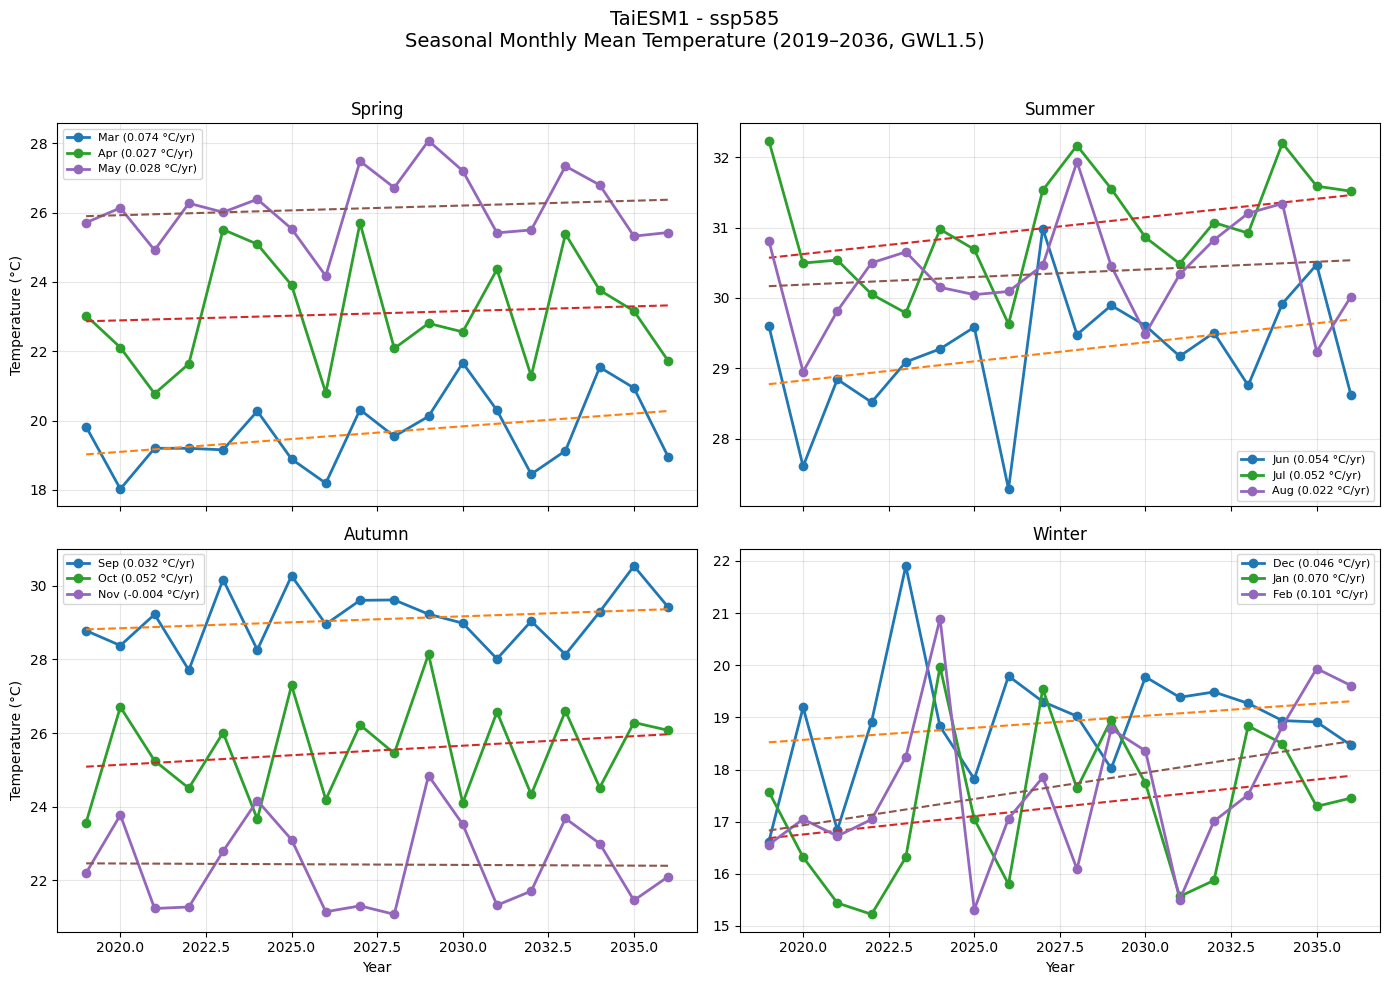

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_TaiESM1_seasonal/TaiESM1_ssp585_seasonal.png


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 設定
# =========================
model = "TaiESM1"
ssps = ["ssp245", "ssp370", "ssp585"]

start_year = 2019
end_year = 2036

season_def = {
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
    "Winter": [12, 1, 2]
}

month_labels = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
    7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}

save_dir = base_dir / "final_TaiESM1_seasonal"
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 日資料 → 月平均
# =========================
def daily_to_monthly(df):
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    monthly = (
        df.groupby(["year", "month"])["value"]
        .mean()
        .reset_index()
    )

    monthly = monthly[
        (monthly["year"] >= start_year) &
        (monthly["year"] <= end_year)
    ].copy()

    return monthly

# =========================
# 主程式
# =========================
for ssp in ssps:

    print(f"Processing {model} - {ssp}")

    df = build_series("GWL1.5", model, ssp)

    if df is None or len(df) == 0:
        print(f"⚠️ {model} - {ssp}: No data")
        continue

    monthly = daily_to_monthly(df)

    if monthly is None or len(monthly) == 0:
        print(f"⚠️ {model} - {ssp}: No monthly data")
        continue

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    axes = axes.flatten()

    for ax, (season, months) in zip(axes, season_def.items()):
        has_data = False

        for m in months:
            sub = monthly[monthly["month"] == m].copy()

            if len(sub) < 2:
                continue

            x = sub["year"].values
            y = sub["value"].values

            slope, intercept = np.polyfit(x, y, 1)
            trend = slope * x + intercept

            label = f"{month_labels[m]} ({slope:.3f} °C/yr)"

            ax.plot(
                x, y,
                marker="o",
                linewidth=2,
                label=label
            )

            ax.plot(
                x, trend,
                linestyle="--",
                linewidth=1.5
            )

            has_data = True

        ax.set_title(season, fontsize=12)
        ax.grid(alpha=0.3)

        if has_data:
            ax.legend(fontsize=8)
        else:
            ax.text(
                0.5, 0.5, "No data",
                transform=ax.transAxes,
                ha="center", va="center",
                color="gray"
            )

    axes[2].set_xlabel("Year")
    axes[3].set_xlabel("Year")
    axes[0].set_ylabel("Temperature (°C)")
    axes[2].set_ylabel("Temperature (°C)")

    fig.suptitle(
        f"{model} - {ssp}\nSeasonal Monthly Mean Temperature (2019–2036, GWL1.5)",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    out_path = save_dir / f"{model}_{ssp}_seasonal.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"✅ Saved: {out_path}")

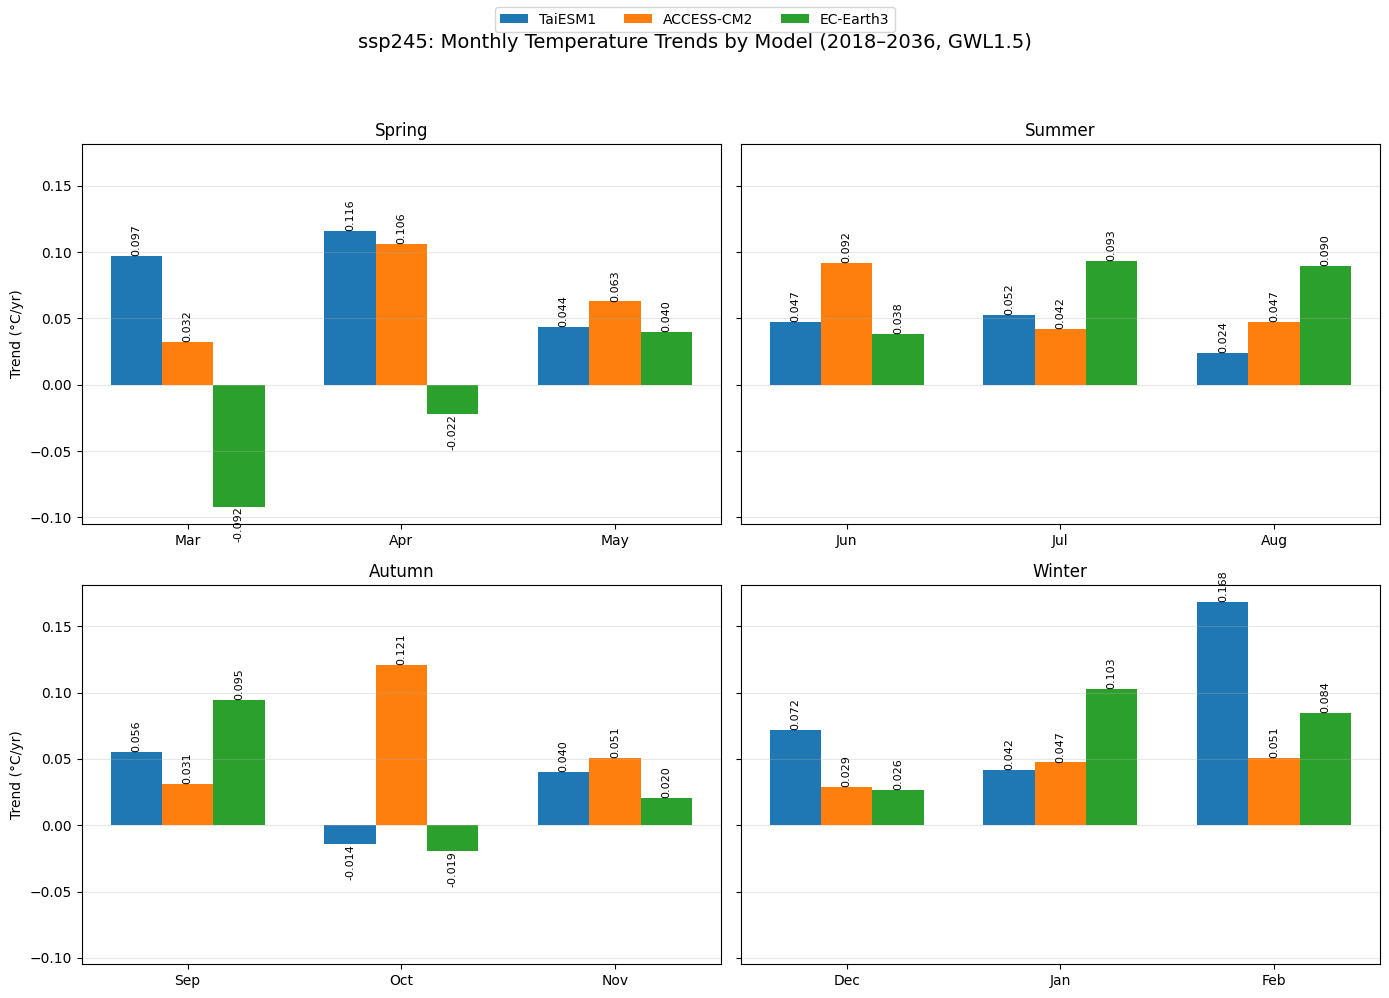

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/barplot_monthly_trends_by_ssp/ssp245_monthly_trends_bar_by_model.png


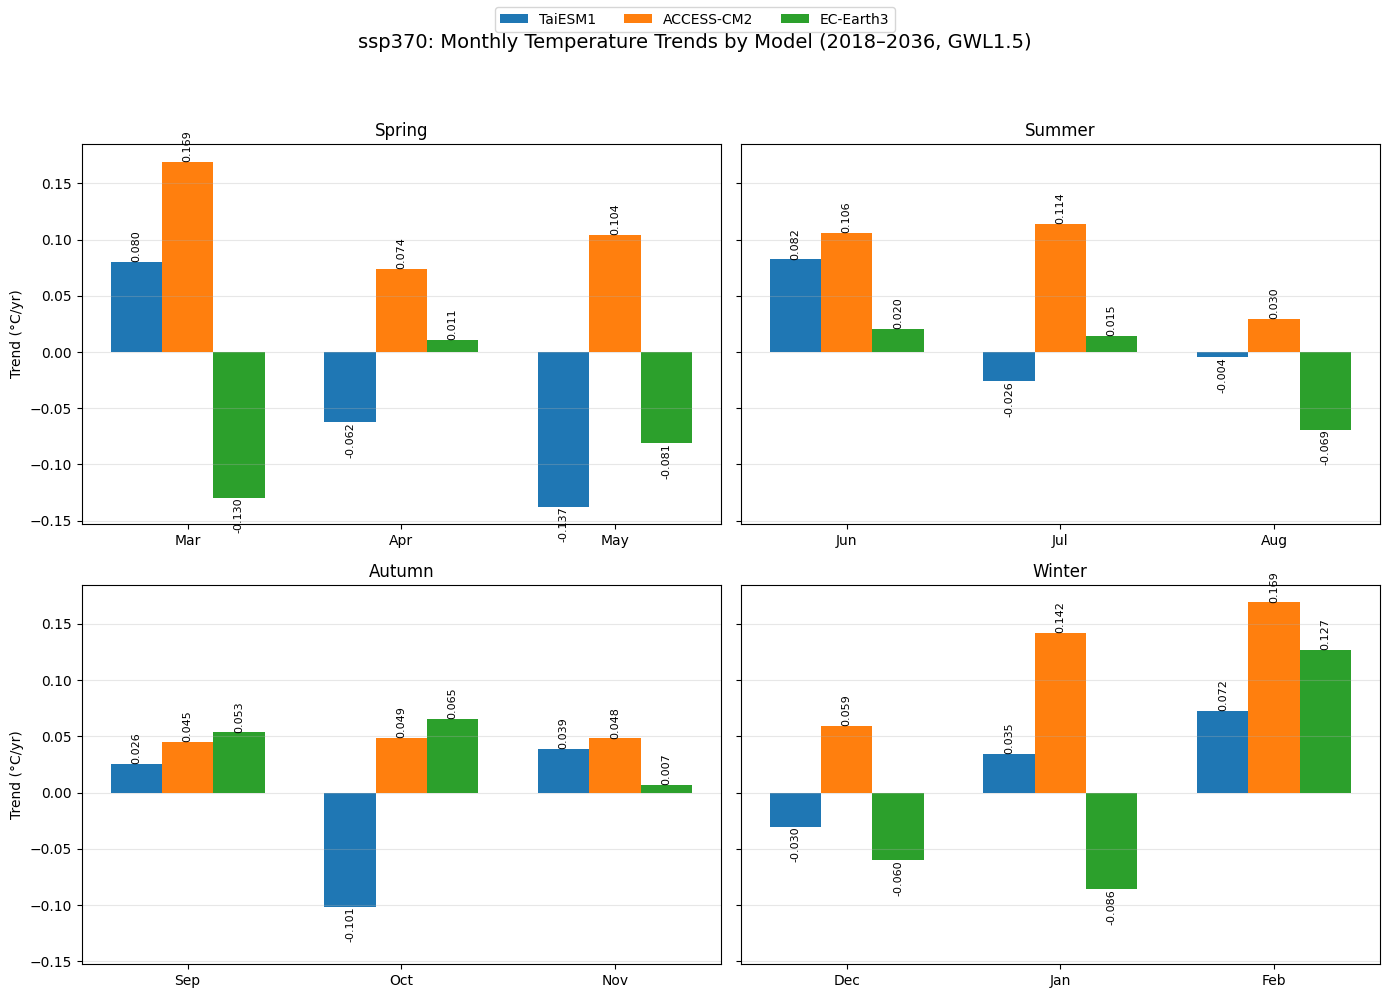

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/barplot_monthly_trends_by_ssp/ssp370_monthly_trends_bar_by_model.png


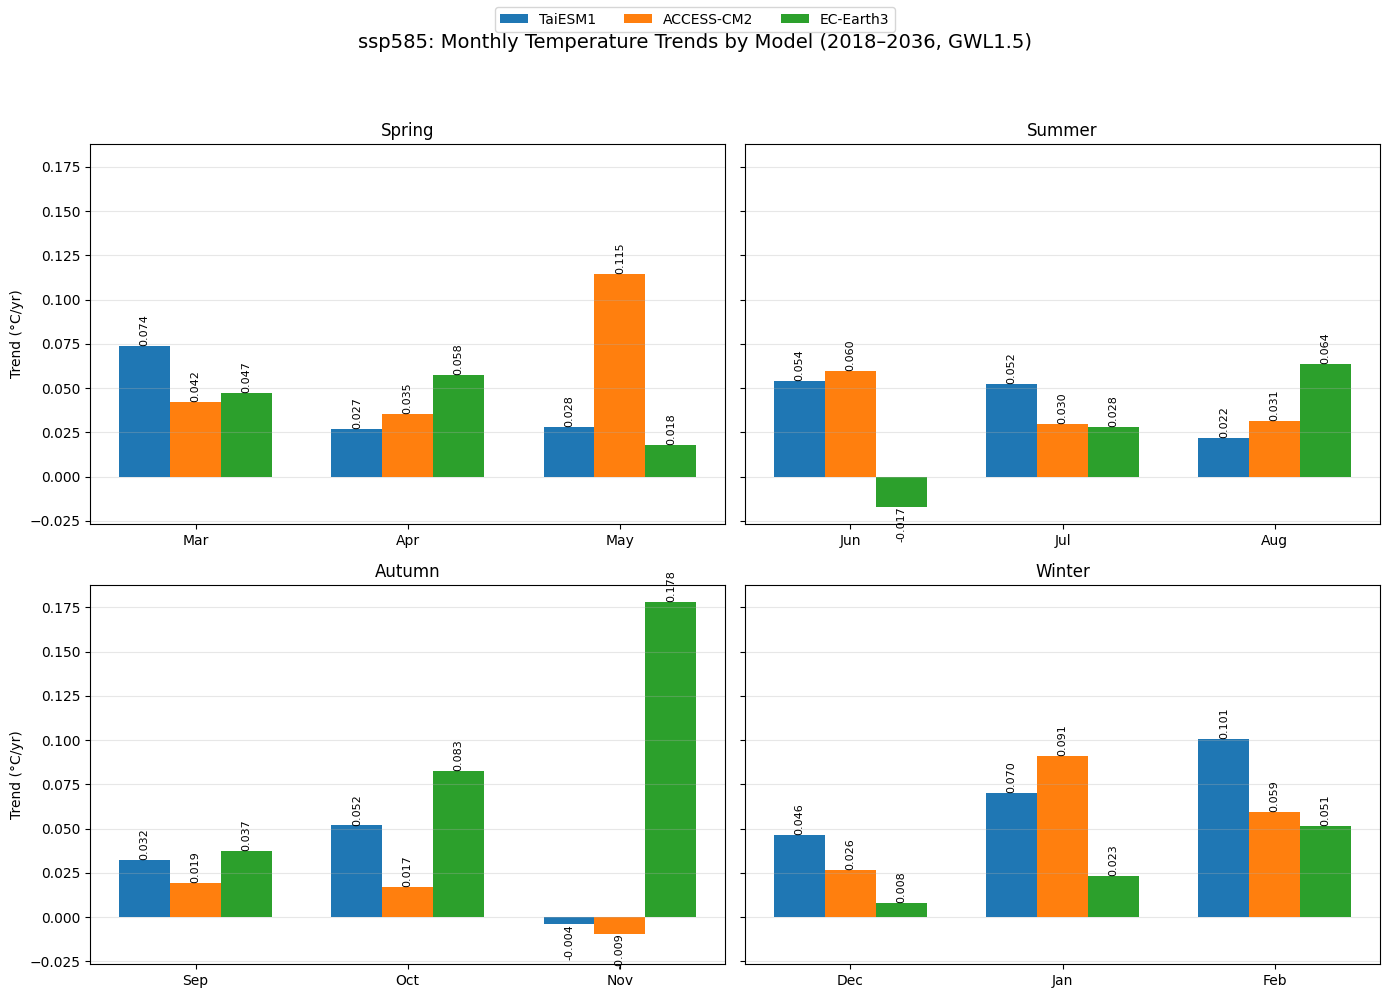

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/barplot_monthly_trends_by_ssp/ssp585_monthly_trends_bar_by_model.png


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 設定
# =========================
models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
ssps = ["ssp245", "ssp370", "ssp585"]

start_year = 2018
end_year = 2036

season_def = {
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
    "Winter": [12, 1, 2]
}

month_labels = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
    7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}

save_dir = base_dir / "barplot_monthly_trends_by_ssp"
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 日資料 → 月平均
# =========================
def daily_to_monthly(df):
    if df is None or len(df) == 0:
        return None

    tmp = df.copy()
    tmp["year"] = tmp["date"].dt.year
    tmp["month"] = tmp["date"].dt.month

    monthly = (
        tmp.groupby(["year", "month"], as_index=False)["value"]
        .mean()
        .sort_values(["year", "month"])
        .reset_index(drop=True)
    )

    monthly = monthly[
        (monthly["year"] >= start_year) & (monthly["year"] <= end_year)
    ].copy()

    if len(monthly) == 0:
        return None

    return monthly

# =========================
# 計算單月趨勢
# =========================
def calc_monthly_trend(monthly_df, month):
    if monthly_df is None or len(monthly_df) == 0:
        return np.nan

    sub = monthly_df[monthly_df["month"] == month].copy()

    if len(sub) < 2:
        return np.nan

    x = sub["year"].values
    y = sub["value"].values

    slope, intercept = np.polyfit(x, y, 1)
    return slope

# =========================
# 建立趨勢表
# =========================
records = []

for ssp in ssps:
    for model in models:
        df = build_series("GWL1.5", model, ssp)

        if df is None or len(df) == 0:
            for m in range(1, 13):
                records.append({
                    "ssp": ssp,
                    "model": model,
                    "month": m,
                    "slope": np.nan
                })
            continue

        monthly = daily_to_monthly(df)

        for m in range(1, 13):
            slope = calc_monthly_trend(monthly, m)
            records.append({
                "ssp": ssp,
                "model": model,
                "month": m,
                "slope": slope
            })

trend_df = pd.DataFrame(records)

# =========================
# 畫圖：每個 SSP 一張圖
# =========================
for ssp in ssps:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
    axes = axes.flatten()

    df_ssp = trend_df[trend_df["ssp"] == ssp].copy()

    for ax, (season, months) in zip(axes, season_def.items()):
        sub = df_ssp[df_ssp["month"].isin(months)].copy()

        # x 軸位置：3 個月份
        x = np.arange(len(months))
        width = 0.24

        for i, model in enumerate(models):
            model_sub = sub[sub["model"] == model].copy()

            # 依照季節內月份順序取值
            yvals = []
            for m in months:
                tmp = model_sub[model_sub["month"] == m]
                if len(tmp) == 0:
                    yvals.append(np.nan)
                else:
                    yvals.append(tmp["slope"].values[0])

            ax.bar(
                x + (i - 1) * width,
                yvals,
                width=width,
                label=model
            )

            # 在長條上標數值
            for xi, yi in zip(x + (i - 1) * width, yvals):
                if pd.notna(yi):
                    ax.text(
                        xi, yi,
                        f"{yi:.3f}",
                        ha="center",
                        va="bottom" if yi >= 0 else "top",
                        fontsize=8,
                        rotation=90
                    )

        ax.set_xticks(x)
        ax.set_xticklabels([month_labels[m] for m in months])
        ax.set_title(season)
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Trend (°C/yr)")
    axes[2].set_ylabel("Trend (°C/yr)")

    handles, labels = axes[0].get_legend_handles_labels()
    if len(handles) > 0:
        fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=10)

    fig.suptitle(
        f"{ssp}: Monthly Temperature Trends by Model (2018–2036, GWL1.5)",
        fontsize=14, y=0.97
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    out_path = save_dir / f"{ssp}_monthly_trends_bar_by_model.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✅ Saved: {out_path}")

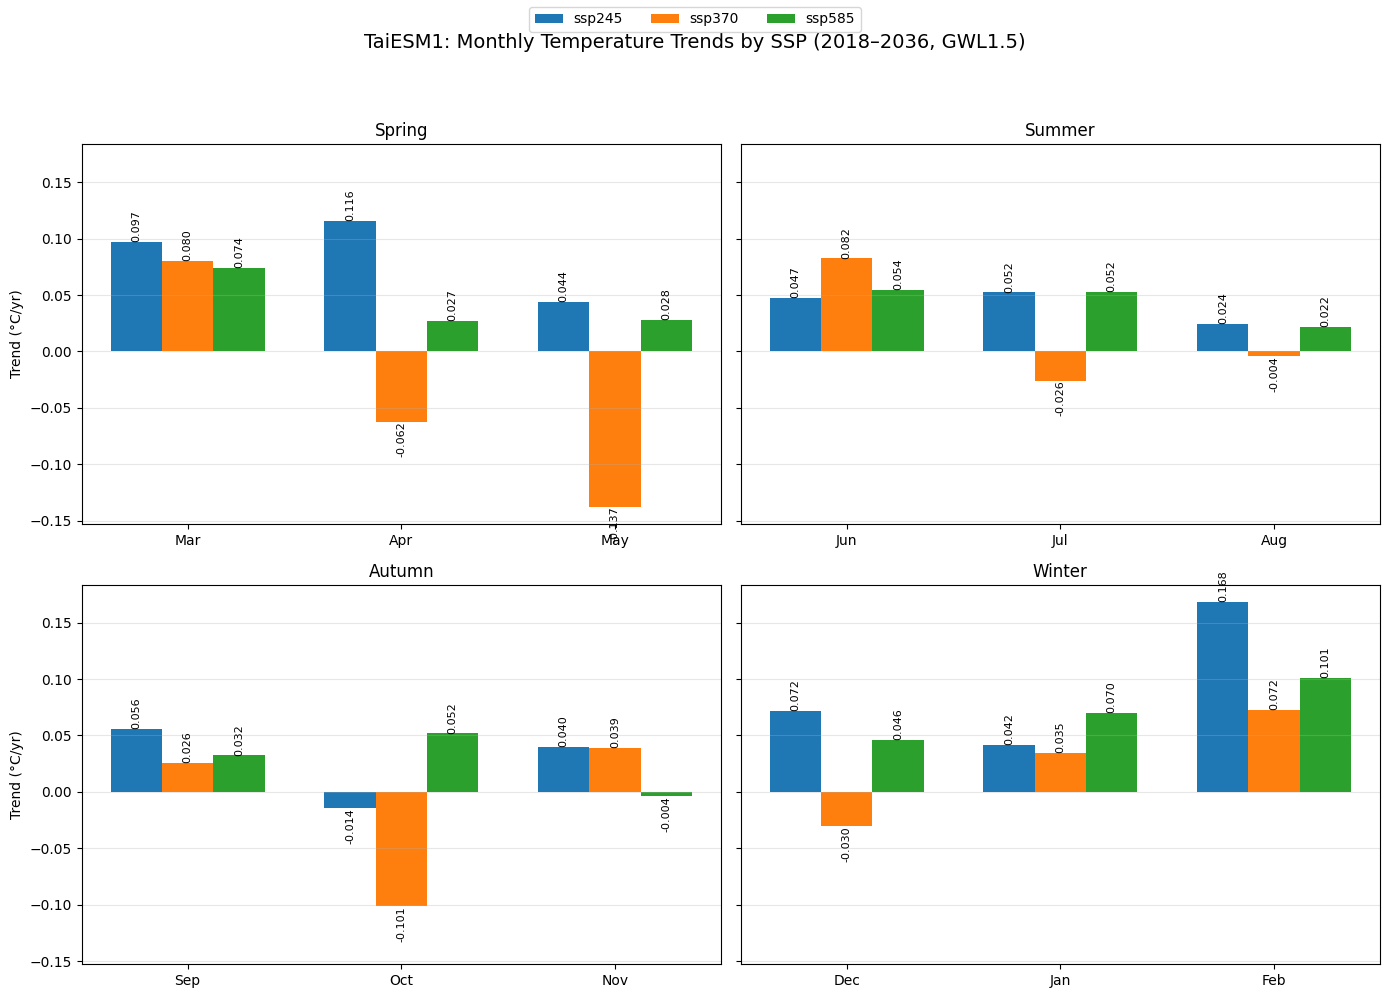

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/barplot_monthly_trends_by_model/TaiESM1_monthly_trends_bar_by_ssp.png


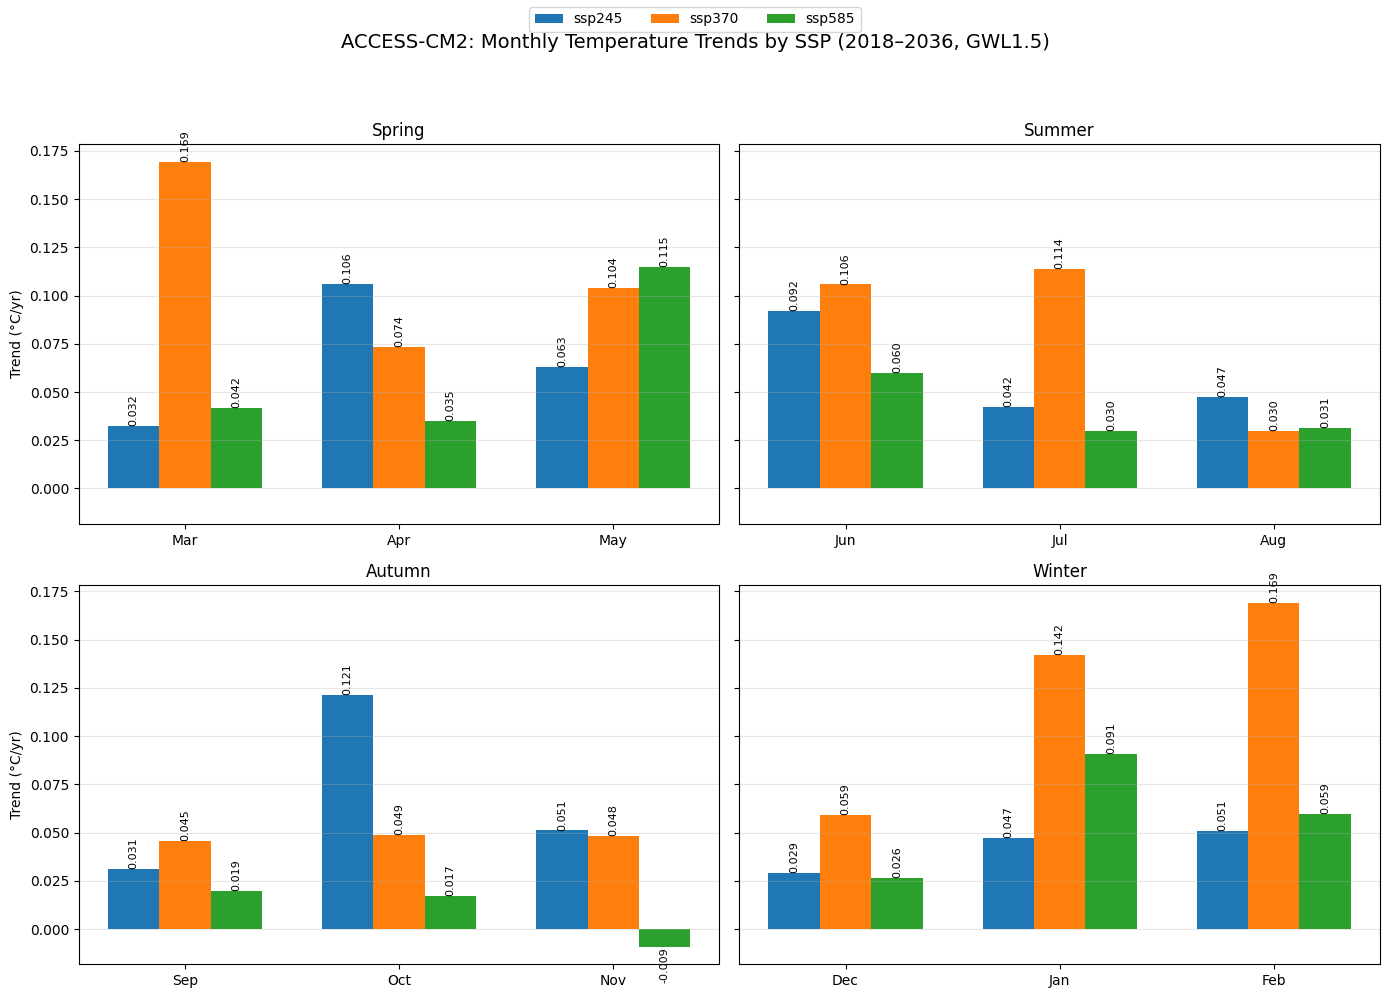

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/barplot_monthly_trends_by_model/ACCESS-CM2_monthly_trends_bar_by_ssp.png


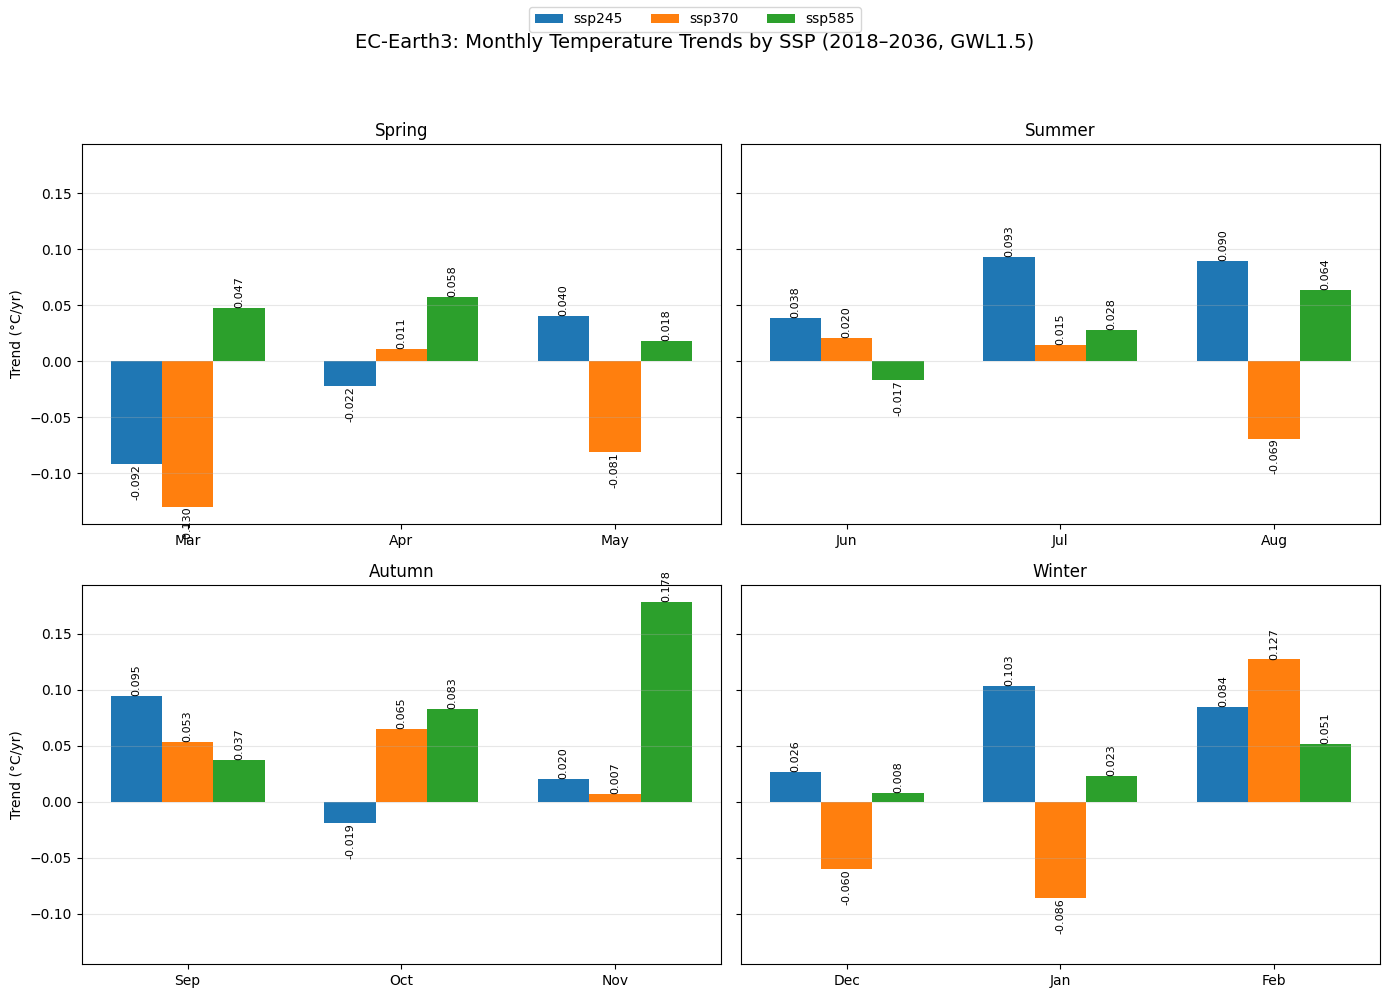

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/barplot_monthly_trends_by_model/EC-Earth3_monthly_trends_bar_by_ssp.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 設定
# =========================
models = ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
ssps = ["ssp245", "ssp370", "ssp585"]

start_year = 2018
end_year = 2036

season_def = {
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
    "Winter": [12, 1, 2]
}

month_labels = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
    7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}

save_dir = base_dir / "barplot_monthly_trends_by_model"
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 日資料 → 月平均
# =========================
def daily_to_monthly(df):
    if df is None or len(df) == 0:
        return None

    tmp = df.copy()
    tmp["year"] = tmp["date"].dt.year
    tmp["month"] = tmp["date"].dt.month

    monthly = (
        tmp.groupby(["year", "month"], as_index=False)["value"]
        .mean()
        .sort_values(["year", "month"])
        .reset_index(drop=True)
    )

    monthly = monthly[
        (monthly["year"] >= start_year) & (monthly["year"] <= end_year)
    ].copy()

    if len(monthly) == 0:
        return None

    return monthly

# =========================
# 計算單月趨勢
# =========================
def calc_monthly_trend(monthly_df, month):
    if monthly_df is None or len(monthly_df) == 0:
        return np.nan

    sub = monthly_df[monthly_df["month"] == month].copy()

    if len(sub) < 2:
        return np.nan

    x = sub["year"].values
    y = sub["value"].values

    slope, intercept = np.polyfit(x, y, 1)
    return slope

# =========================
# 建立趨勢表
# =========================
records = []

for model in models:
    for ssp in ssps:
        df = build_series("GWL1.5", model, ssp)

        if df is None or len(df) == 0:
            for m in range(1, 13):
                records.append({
                    "model": model,
                    "ssp": ssp,
                    "month": m,
                    "slope": np.nan
                })
            continue

        monthly = daily_to_monthly(df)

        for m in range(1, 13):
            slope = calc_monthly_trend(monthly, m)
            records.append({
                "model": model,
                "ssp": ssp,
                "month": m,
                "slope": slope
            })

trend_df = pd.DataFrame(records)

# =========================
# 畫圖：每個 model 一張圖
# =========================
for model in models:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
    axes = axes.flatten()

    df_model = trend_df[trend_df["model"] == model].copy()

    for ax, (season, months) in zip(axes, season_def.items()):
        sub = df_model[df_model["month"].isin(months)].copy()

        x = np.arange(len(months))
        width = 0.24

        for i, ssp in enumerate(ssps):
            ssp_sub = sub[sub["ssp"] == ssp].copy()

            yvals = []
            for m in months:
                tmp = ssp_sub[ssp_sub["month"] == m]
                if len(tmp) == 0:
                    yvals.append(np.nan)
                else:
                    yvals.append(tmp["slope"].values[0])

            ax.bar(
                x + (i - 1) * width,
                yvals,
                width=width,
                label=ssp
            )

            for xi, yi in zip(x + (i - 1) * width, yvals):
                if pd.notna(yi):
                    ax.text(
                        xi, yi,
                        f"{yi:.3f}",
                        ha="center",
                        va="bottom" if yi >= 0 else "top",
                        fontsize=8,
                        rotation=90
                    )

        ax.set_xticks(x)
        ax.set_xticklabels([month_labels[m] for m in months])
        ax.set_title(season)
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Trend (°C/yr)")
    axes[2].set_ylabel("Trend (°C/yr)")

    handles, labels = axes[0].get_legend_handles_labels()
    if len(handles) > 0:
        fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=10)

    fig.suptitle(
        f"{model}: Monthly Temperature Trends by SSP (2018–2036, GWL1.5)",
        fontsize=14, y=0.97
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    out_path = save_dir / f"{model}_monthly_trends_bar_by_ssp.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✅ Saved: {out_path}")

In [28]:
from pathlib import Path
from collections import defaultdict

gwl_dir = Path("/Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/GWL1.5")

ssps = ["ssp245", "ssp370", "ssp585"]
target_years = set(range(2018, 2037))

data = defaultdict(lambda: defaultdict(set))

for f in gwl_dir.glob("*.csv"):
    parts = f.stem.split("_")
    if len(parts) < 3:
        continue

    year_part = parts[-1]
    model_part = parts[-2]
    ssp_part = parts[-3]

    if not year_part.isdigit():
        continue

    year = int(year_part)

    if ssp_part in ssps and year in target_years:
        data[model_part][ssp_part].add(year)

qualified_models = []
incomplete_info = {}

for model, ssp_dict in data.items():
    missing = {}
    complete = True

    for ssp in ssps:
        years_have = ssp_dict.get(ssp, set())
        years_missing = sorted(target_years - years_have)
        if years_missing:
            complete = False
            missing[ssp] = years_missing

    if complete:
        qualified_models.append(model)
    else:
        incomplete_info[model] = missing

qualified_models = sorted(qualified_models)

print("=== 符合條件的模式 ===")
for m in qualified_models:
    print(m)
print(f"共 {len(qualified_models)} 個模式\n")

print("=== 不符合條件的模式（缺少年份） ===")
for model in sorted(incomplete_info):
    print(f"\n{model}")
    for ssp in ssps:
        miss = incomplete_info[model].get(ssp, [])
        if miss:
            print(f"  {ssp}: 缺 {miss}")
        else:
            print(f"  {ssp}: 完整")

=== 符合條件的模式 ===
共 0 個模式

=== 不符合條件的模式（缺少年份） ===

ACCESS-CM2
  ssp245: 缺 [2018]
  ssp370: 完整
  ssp585: 缺 [2036]

ACCESS-ESM1-5
  ssp245: 缺 [2018, 2019]
  ssp370: 缺 [2018, 2019, 2020, 2021, 2022, 2023]
  ssp585: 完整

AWI-CM-1-1-MR
  ssp245: 缺 [2031, 2032, 2033, 2034, 2035, 2036]
  ssp370: 缺 [2033, 2034, 2035, 2036]
  ssp585: 缺 [2030, 2031, 2032, 2033, 2034, 2035, 2036]

BCC-CSM2-MR
  ssp245: 缺 [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  ssp370: 缺 [2018, 2019, 2020, 2021, 2022]
  ssp585: 缺 [2018, 2019, 2020]

CMCC-ESM2
  ssp245: 缺 [2018, 2019, 2020]
  ssp370: 缺 [2018, 2019, 2020, 2021]
  ssp585: 缺 [2018, 2019]

CanESM5
  ssp245: 缺 [2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036]
  ssp370: 缺 [2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036]
  ssp585: 缺 [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036]

EC-Earth3
  ssp245: 缺 [2033, 2034, 2035, 2036]
  ssp370: 缺 [2033, 2034, 2035, 2036]
  ssp5

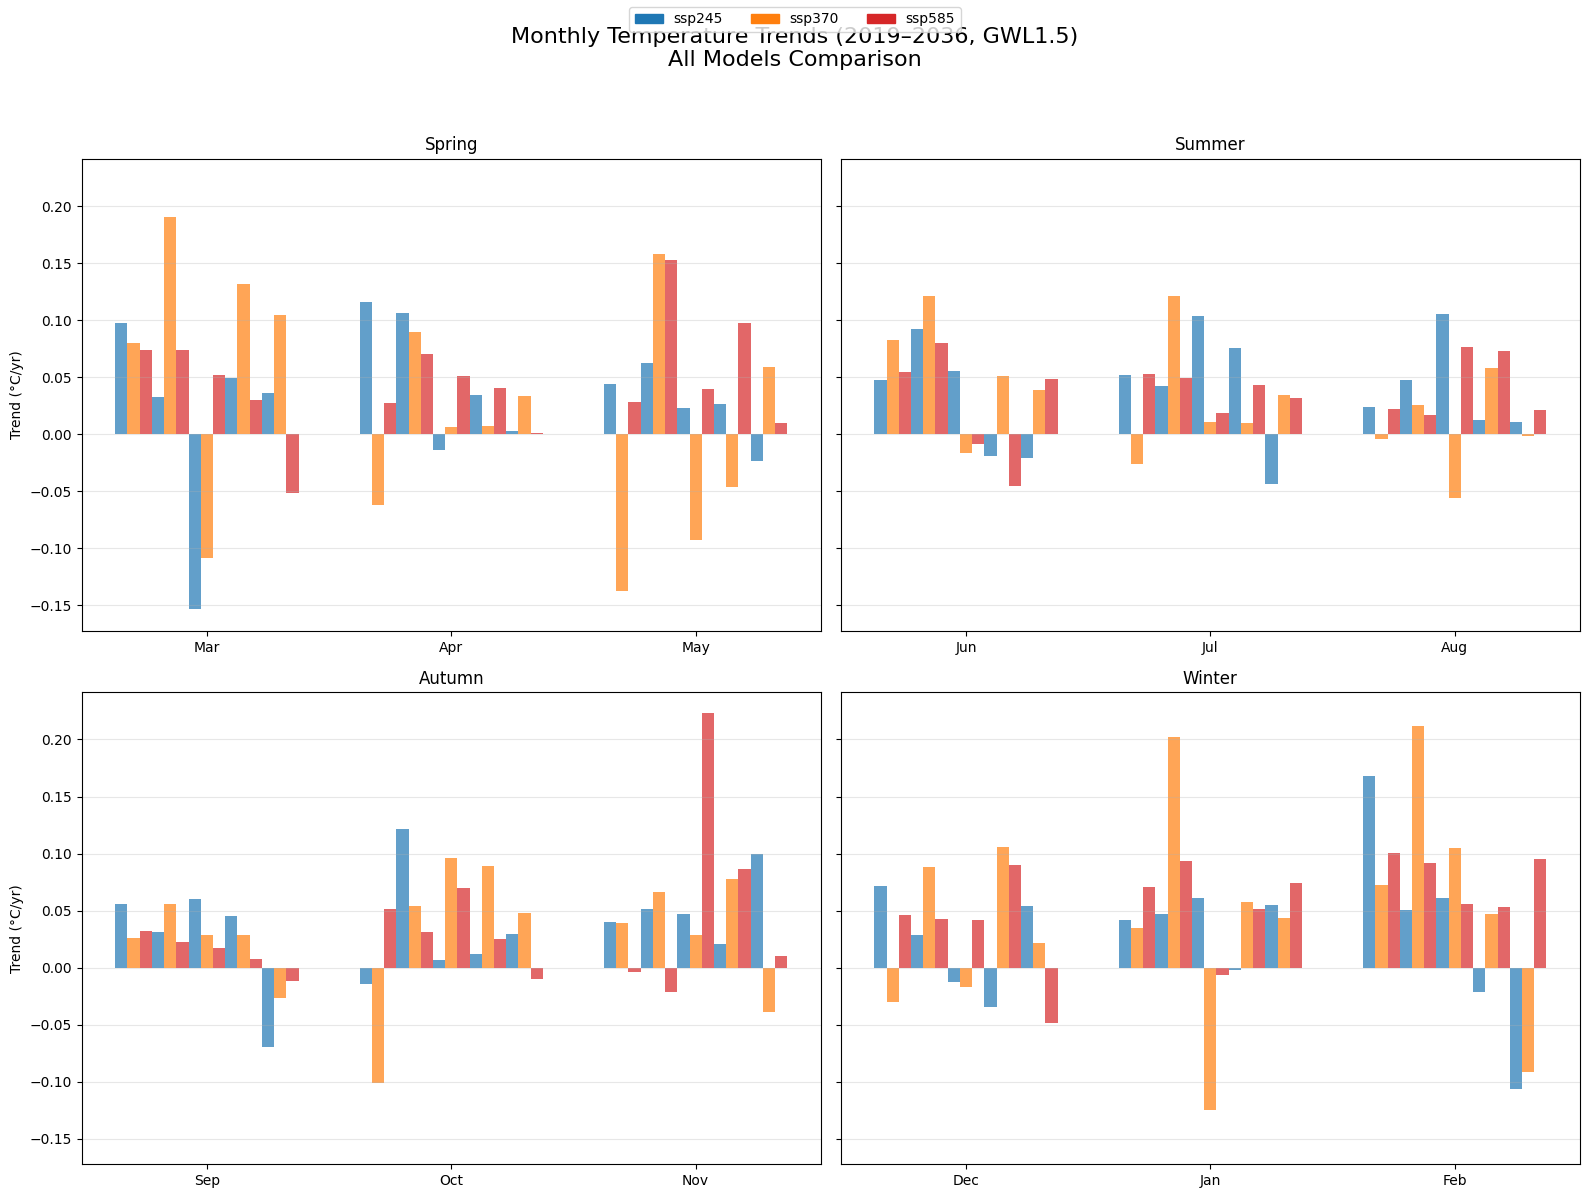

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/FINAL_ALL_MODELS/ALL_models_comparison.png


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 設定
# =========================
models = [
    "TaiESM1",
    "ACCESS-CM2",
    "EC-Earth3",
    "EC-Earth3-Veg-LR",
    "FGOALS-g3"
]

ssps = ["ssp245", "ssp370", "ssp585"]

start_year = 2019
end_year = 2036

season_def = {
    "Spring": [3,4,5],
    "Summer": [6,7,8],
    "Autumn": [9,10,11],
    "Winter": [12,1,2]
}

month_labels = {
    1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
    7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}

colors = {
    "ssp245": "#1f77b4",
    "ssp370": "#ff7f0e",
    "ssp585": "#d62728"
}

save_dir = base_dir / "FINAL_ALL_MODELS"
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 日 → 月平均
# =========================
def daily_to_monthly(df):
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    monthly = df.groupby(["year","month"])["value"].mean().reset_index()

    return monthly[
        (monthly["year"]>=start_year) &
        (monthly["year"]<=end_year)
    ]

# =========================
# 計算 slope
# =========================
def calc_slope(monthly, m):
    sub = monthly[monthly["month"]==m]

    if len(sub) < 2:
        return np.nan

    x = sub["year"].values
    y = sub["value"].values

    slope, _ = np.polyfit(x, y, 1)
    return slope

# =========================
# 建立資料表
# =========================
records = []

for model in models:
    for ssp in ssps:

        df = build_series("GWL1.5", model, ssp)

        if df is None or len(df)==0:
            continue

        monthly = daily_to_monthly(df)

        for m in range(1,13):
            slope = calc_slope(monthly, m)

            records.append({
                "model": model,
                "ssp": ssp,
                "month": m,
                "slope": slope
            })

trend_df = pd.DataFrame(records)

# =========================
# 畫圖
# =========================
fig, axes = plt.subplots(2,2, figsize=(16,12), sharey=True)
axes = axes.flatten()

bar_width = 0.15

for ax, (season, months) in zip(axes, season_def.items()):

    x = np.arange(len(months))

    for i, model in enumerate(models):
        for j, ssp in enumerate(ssps):

            subset = trend_df[
                (trend_df["model"]==model) &
                (trend_df["ssp"]==ssp)
            ]

            yvals = []
            for m in months:
                tmp = subset[subset["month"]==m]
                if len(tmp)==0:
                    yvals.append(np.nan)
                else:
                    yvals.append(tmp["slope"].values[0])

            offset = (i - 2)*bar_width + (j-1)*bar_width/3

            ax.bar(
                x + offset,
                yvals,
                width=bar_width/3,
                color=colors[ssp],
                alpha=0.7
            )

    ax.set_xticks(x)
    ax.set_xticklabels([month_labels[m] for m in months])
    ax.set_title(season)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Trend (°C/yr)")
axes[2].set_ylabel("Trend (°C/yr)")

# 圖例（只放 SSP）
handles = [
    plt.Rectangle((0,0),1,1,color=colors[s]) for s in ssps
]
labels = ssps
fig.legend(handles, labels, loc="upper center", ncol=3)

fig.suptitle(
    "Monthly Temperature Trends (2019–2036, GWL1.5)\nAll Models Comparison",
    fontsize=16
)

plt.tight_layout(rect=[0,0,1,0.95])

out_path = save_dir / "ALL_models_comparison.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"✅ Saved: {out_path}")

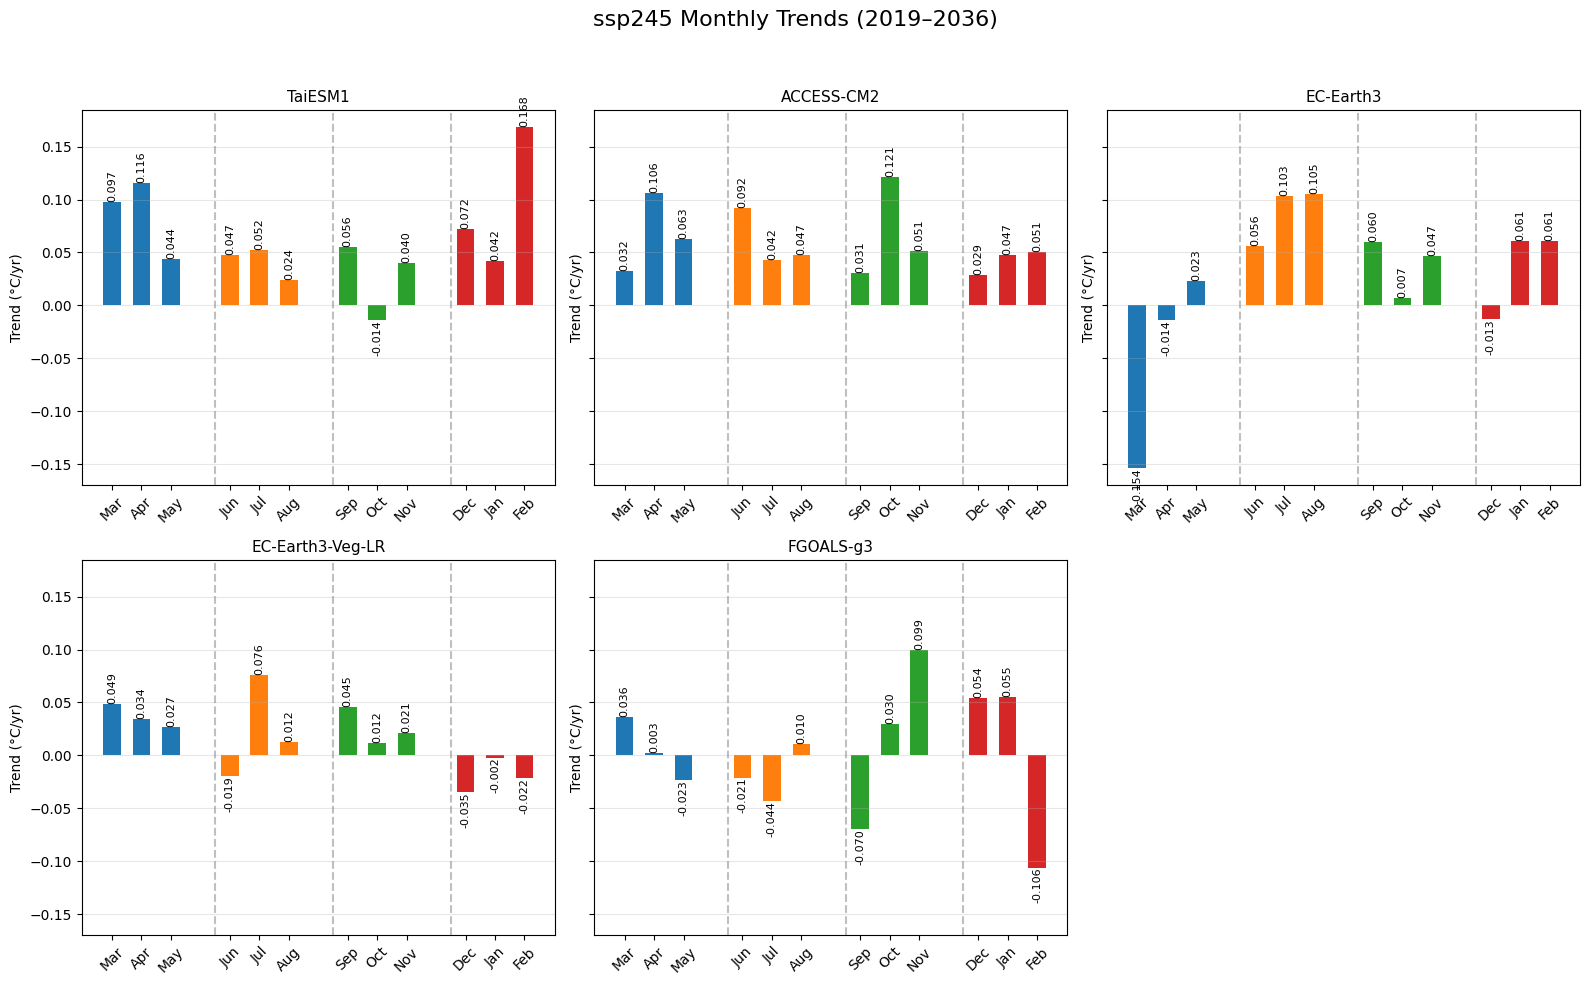

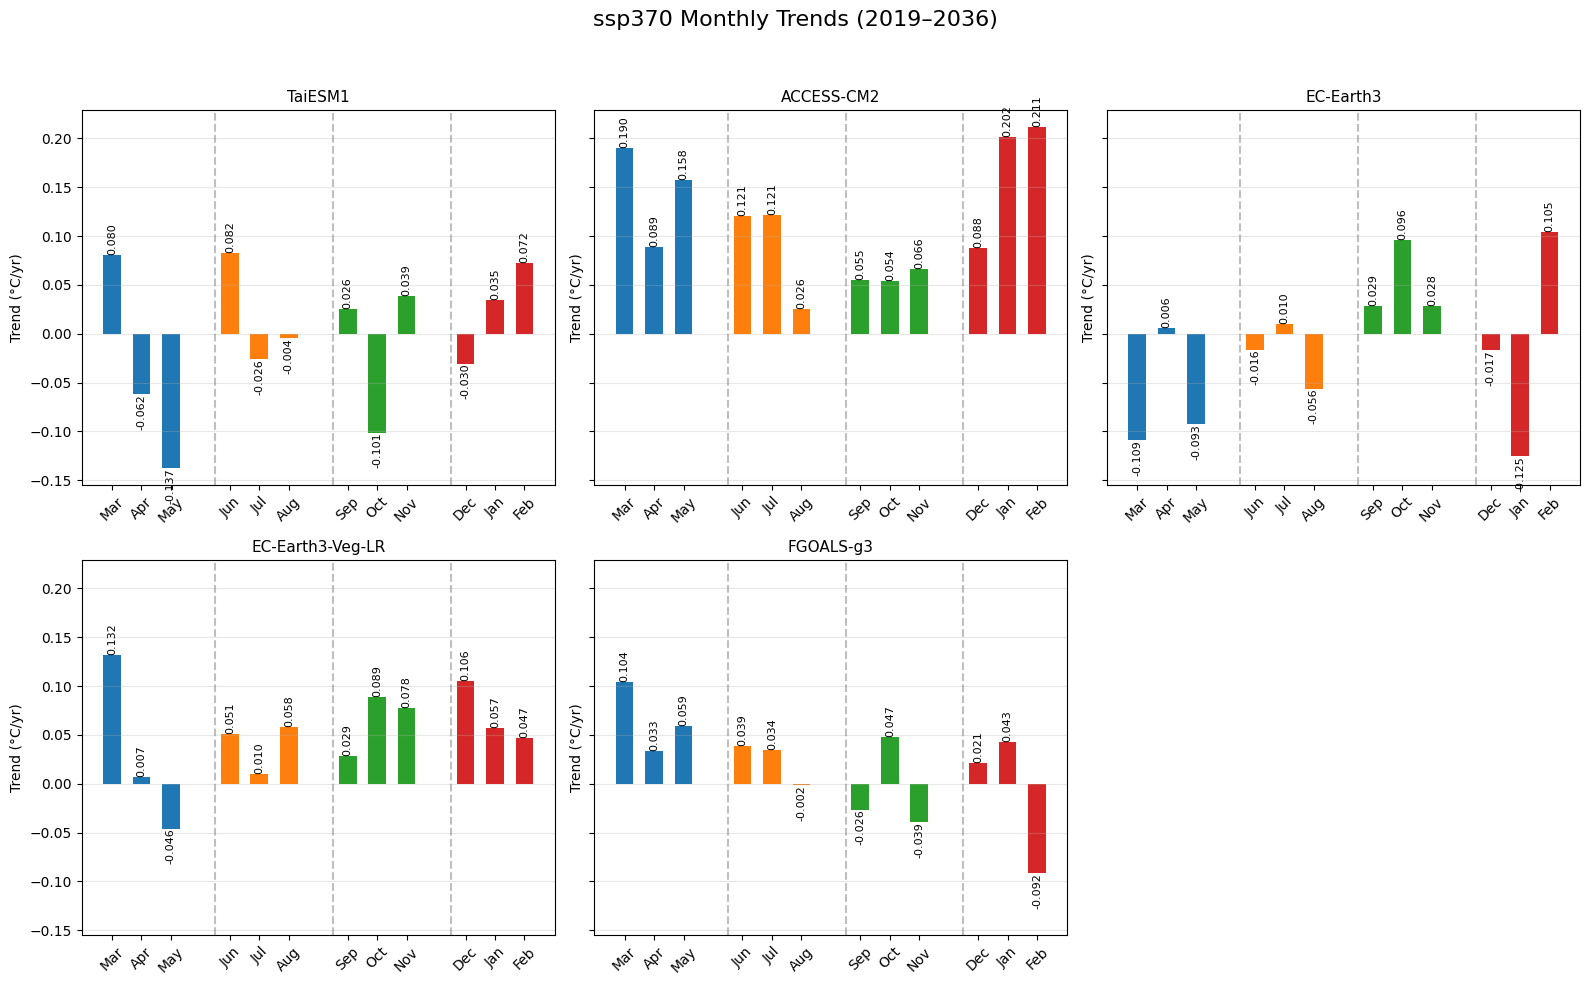

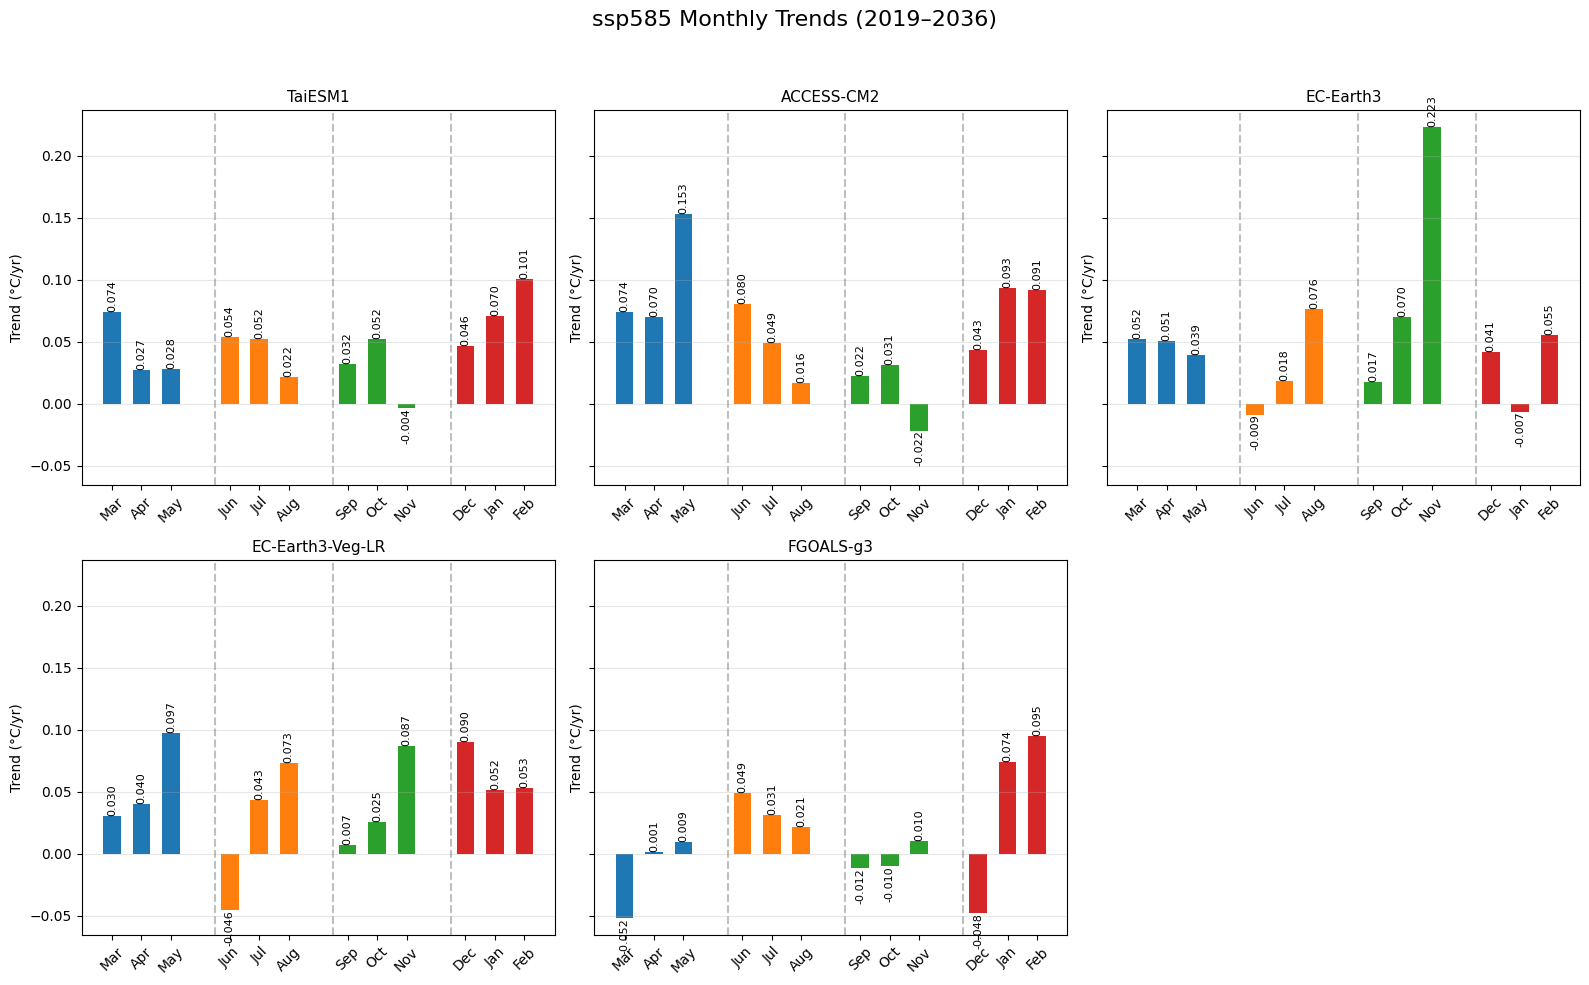

In [39]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "TaiESM1",
    "ACCESS-CM2",
    "EC-Earth3",
    "EC-Earth3-Veg-LR",
    "FGOALS-g3"
]

ssps = ["ssp245", "ssp370", "ssp585"]

# 假設前面已經有：
# trend_df
# season_def
# month_labels

for ssp in ssps:

    fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)
    axes = axes.flatten()

    for ax, model in zip(axes, models):

        subset = trend_df[
            (trend_df["model"] == model) &
            (trend_df["ssp"] == ssp)
        ]

        xticks = []
        xticklabels = []

        for i, (season, months) in enumerate(season_def.items()):

            x = np.arange(len(months)) + i * 4  # 每季留一格間距

            yvals = []
            for m in months:
                tmp = subset[subset["month"] == m]
                if len(tmp) == 0:
                    yvals.append(np.nan)
                else:
                    yvals.append(tmp["slope"].values[0])

            ax.bar(x, yvals, width=0.6)

            # x 軸標籤
            xticks.extend(x)
            xticklabels.extend([month_labels[m] for m in months])

            # bar 上標數值
            for xi, yi in zip(x, yvals):
                if pd.notna(yi):
                    ax.text(
                        xi,
                        yi,
                        f"{yi:.3f}",
                        ha="center",
                        va="bottom" if yi >= 0 else "top",
                        fontsize=8,
                        rotation=90
                    )

            # 季節分隔線
            if i > 0:
                ax.axvline(i * 4 - 0.5, color="gray", linestyle="--", alpha=0.5)

        ax.set_title(model, fontsize=11)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, rotation=45)
        ax.set_ylabel("Trend (°C/yr)")
        ax.grid(axis="y", alpha=0.3)

    # 最後一格空白
    if len(axes) > len(models):
        axes[-1].axis("off")

    fig.suptitle(f"{ssp} Monthly Trends (2019–2036)", fontsize=16)

    out_path = save_dir / "ALL_models_Monthly＿Trends.png"
    plt.savefig(out_path, dpi=300)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Processing EC-Earth3-Veg-LR - ssp245


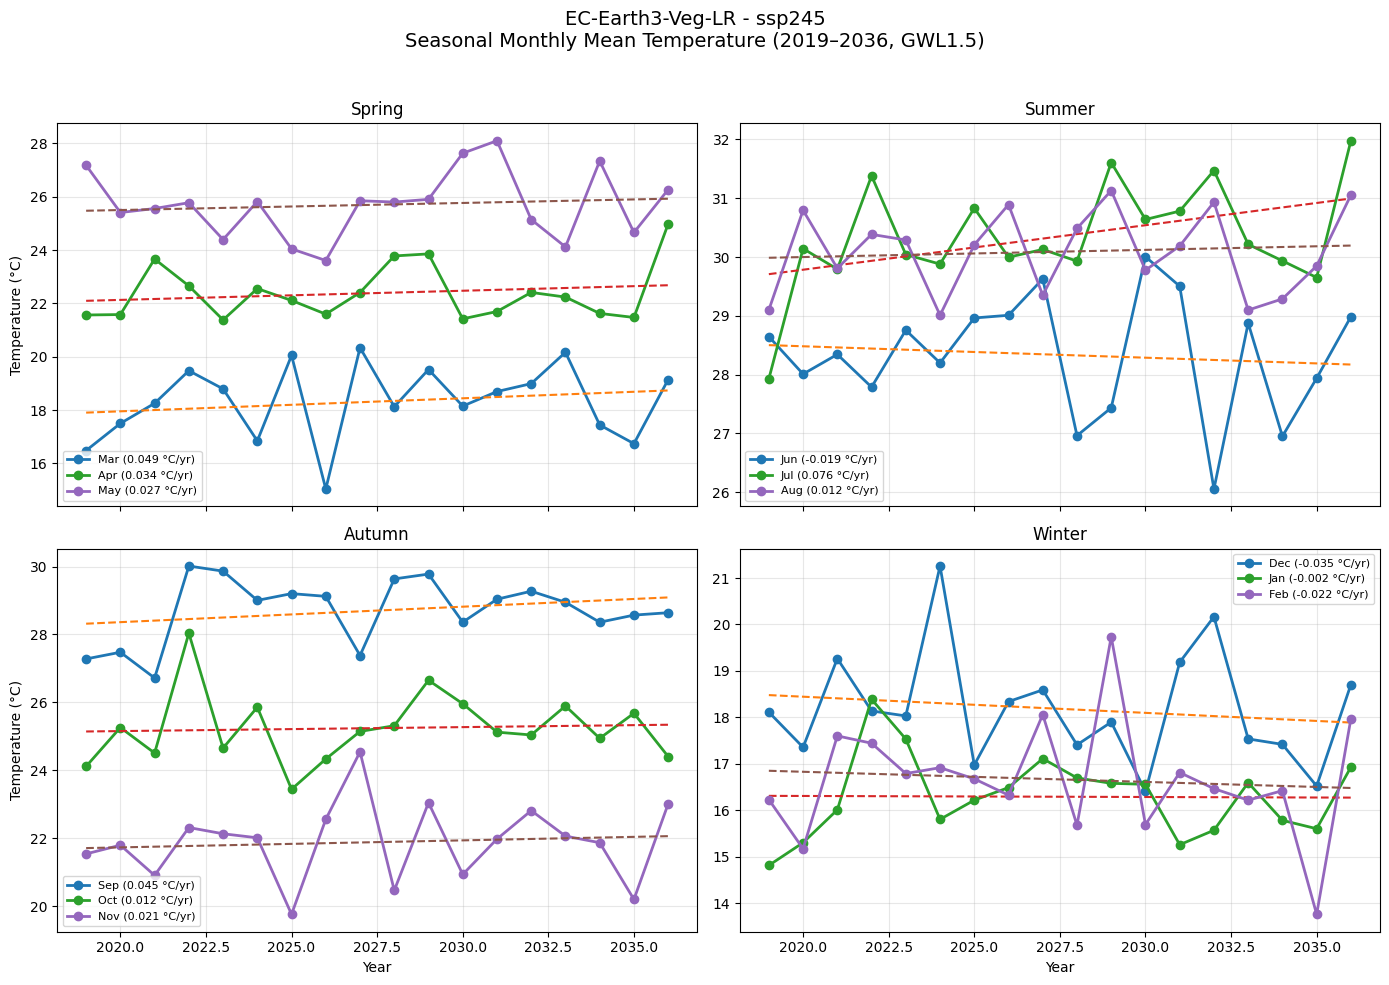

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_EC-Earth3-Veg-LR_seasonal/EC-Earth3-Veg-LR_ssp245_seasonal.png
Processing EC-Earth3-Veg-LR - ssp370


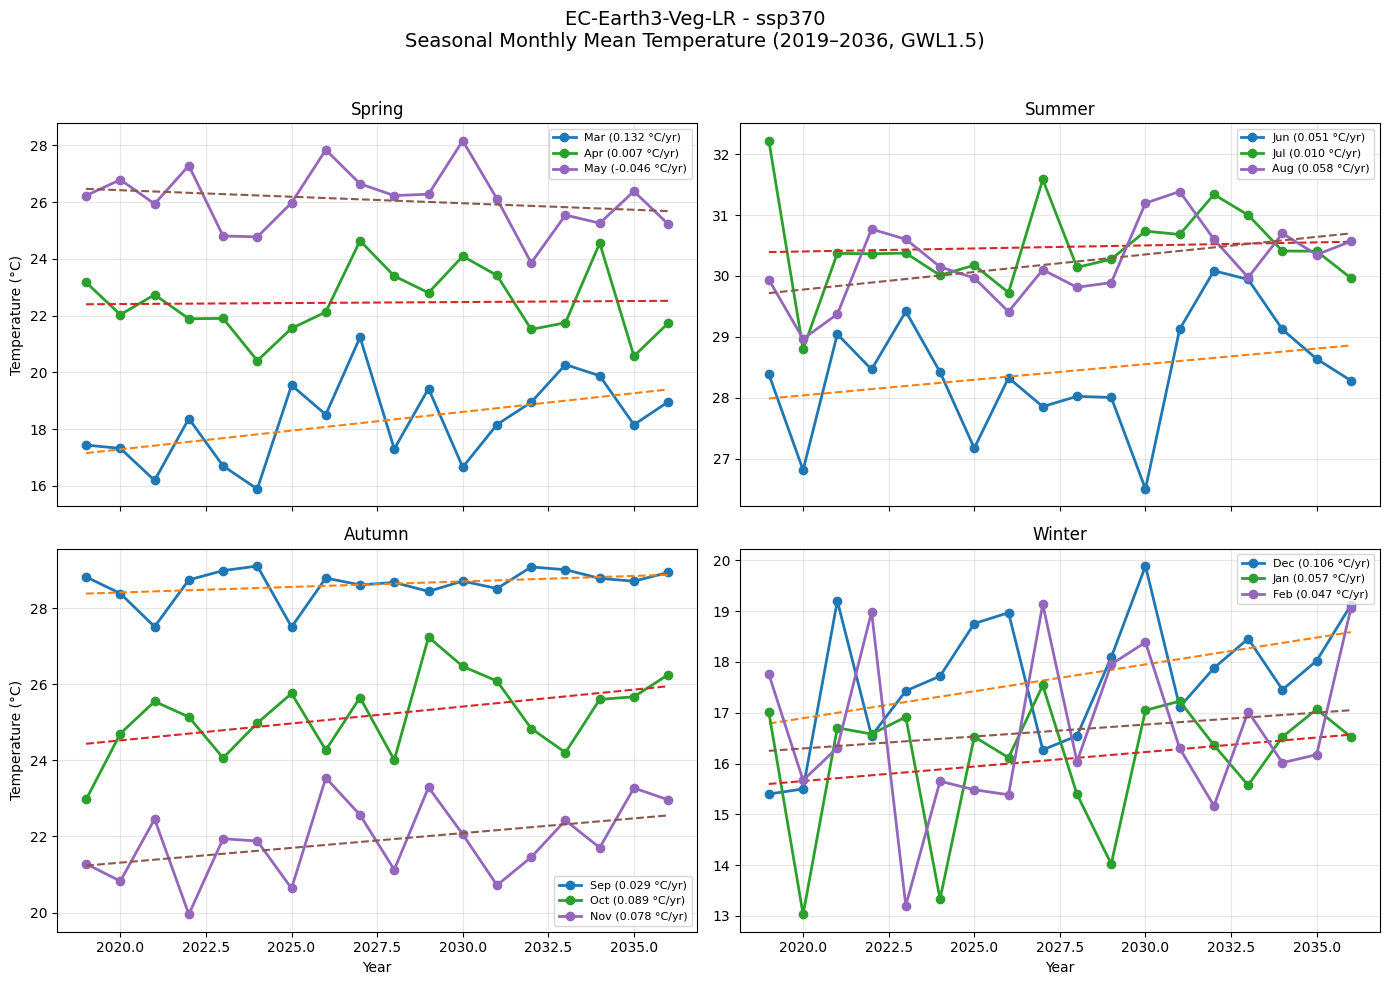

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_EC-Earth3-Veg-LR_seasonal/EC-Earth3-Veg-LR_ssp370_seasonal.png
Processing EC-Earth3-Veg-LR - ssp585


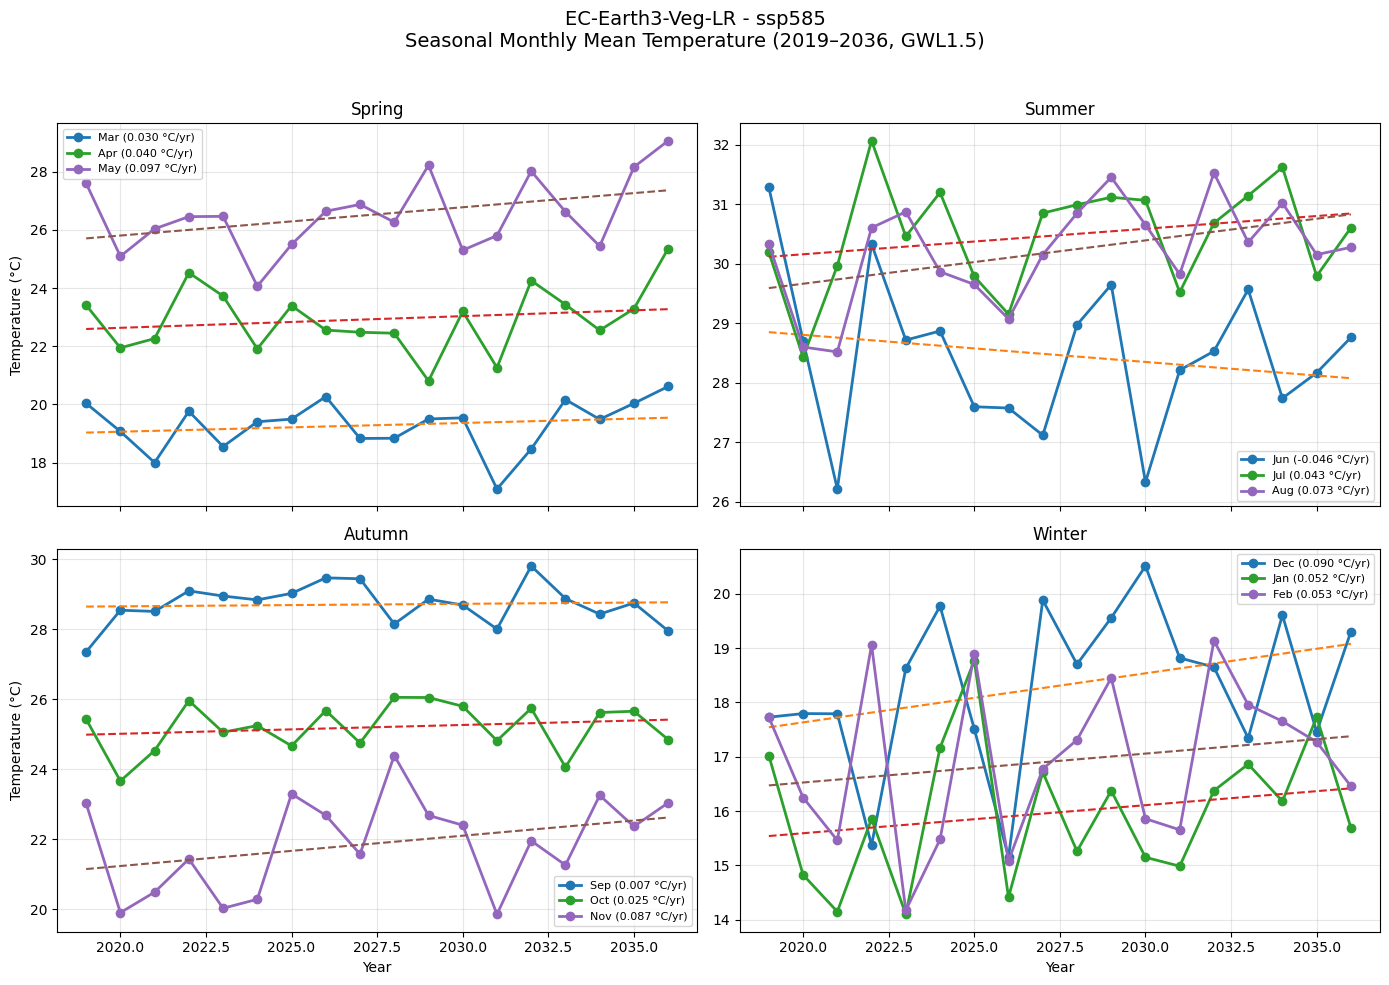

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_EC-Earth3-Veg-LR_seasonal/EC-Earth3-Veg-LR_ssp585_seasonal.png


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 設定
# =========================
model = "EC-Earth3-Veg-LR"
ssps = ["ssp245", "ssp370", "ssp585"]

start_year = 2019
end_year = 2036

season_def = {
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
    "Winter": [12, 1, 2]
}

month_labels = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
    7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}

save_dir = base_dir / "final_EC-Earth3-Veg-LR_seasonal"
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 日資料 → 月平均
# =========================
def daily_to_monthly(df):
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    monthly = (
        df.groupby(["year", "month"])["value"]
        .mean()
        .reset_index()
    )

    monthly = monthly[
        (monthly["year"] >= start_year) &
        (monthly["year"] <= end_year)
    ].copy()

    return monthly

# =========================
# 主程式
# =========================
for ssp in ssps:

    print(f"Processing {model} - {ssp}")

    df = build_series("GWL1.5", model, ssp)

    if df is None or len(df) == 0:
        print(f"⚠️ {model} - {ssp}: No data")
        continue

    monthly = daily_to_monthly(df)

    if monthly is None or len(monthly) == 0:
        print(f"⚠️ {model} - {ssp}: No monthly data")
        continue

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    axes = axes.flatten()

    for ax, (season, months) in zip(axes, season_def.items()):
        has_data = False

        for m in months:
            sub = monthly[monthly["month"] == m].copy()

            if len(sub) < 2:
                continue

            x = sub["year"].values
            y = sub["value"].values

            slope, intercept = np.polyfit(x, y, 1)
            trend = slope * x + intercept

            label = f"{month_labels[m]} ({slope:.3f} °C/yr)"

            ax.plot(
                x, y,
                marker="o",
                linewidth=2,
                label=label
            )

            ax.plot(
                x, trend,
                linestyle="--",
                linewidth=1.5
            )

            has_data = True

        ax.set_title(season, fontsize=12)
        ax.grid(alpha=0.3)

        if has_data:
            ax.legend(fontsize=8)
        else:
            ax.text(
                0.5, 0.5, "No data",
                transform=ax.transAxes,
                ha="center", va="center",
                color="gray"
            )

    axes[2].set_xlabel("Year")
    axes[3].set_xlabel("Year")
    axes[0].set_ylabel("Temperature (°C)")
    axes[2].set_ylabel("Temperature (°C)")

    fig.suptitle(
        f"{model} - {ssp}\nSeasonal Monthly Mean Temperature (2019–2036, GWL1.5)",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    out_path = save_dir / f"{model}_{ssp}_seasonal.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"✅ Saved: {out_path}")

Processing FGOALS-g3 - ssp245


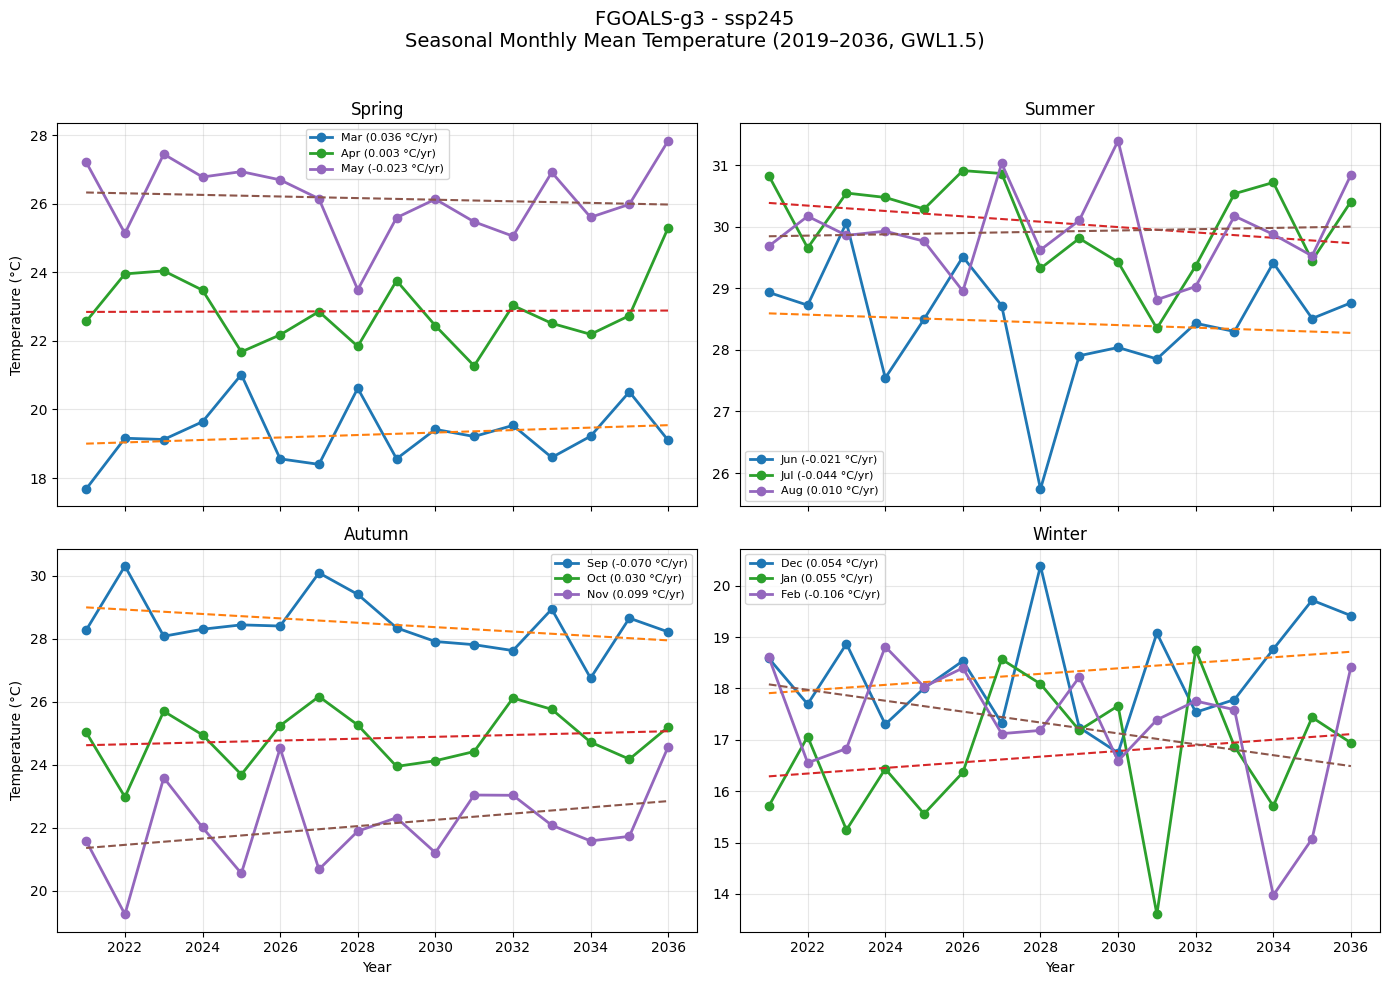

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_FGOALS-g3_seasonal/FGOALS-g3_ssp245_seasonal.png
Processing FGOALS-g3 - ssp370


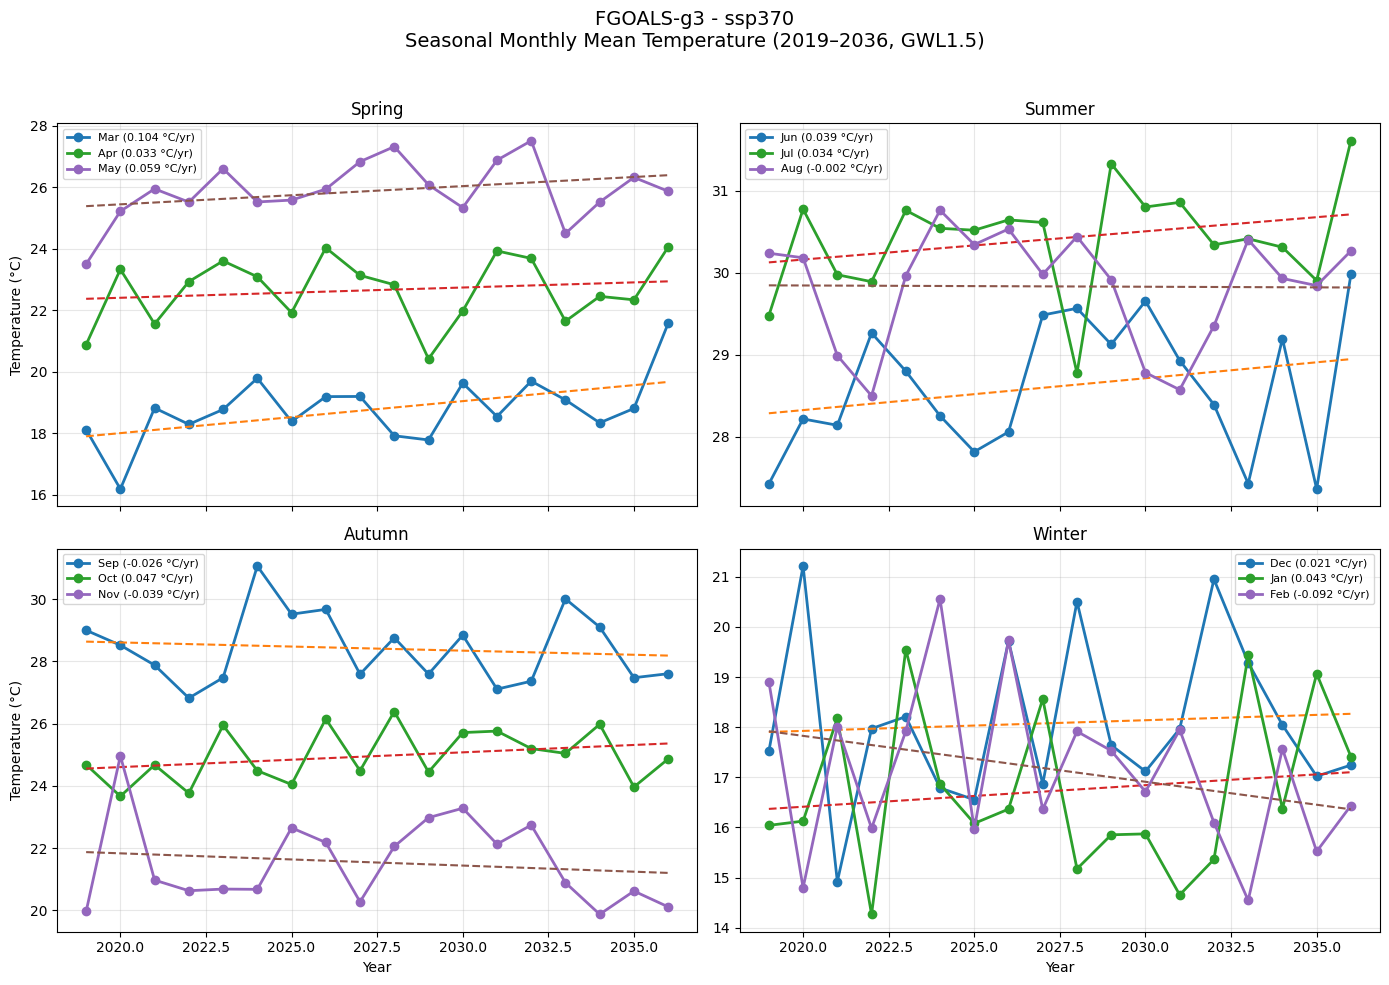

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_FGOALS-g3_seasonal/FGOALS-g3_ssp370_seasonal.png
Processing FGOALS-g3 - ssp585


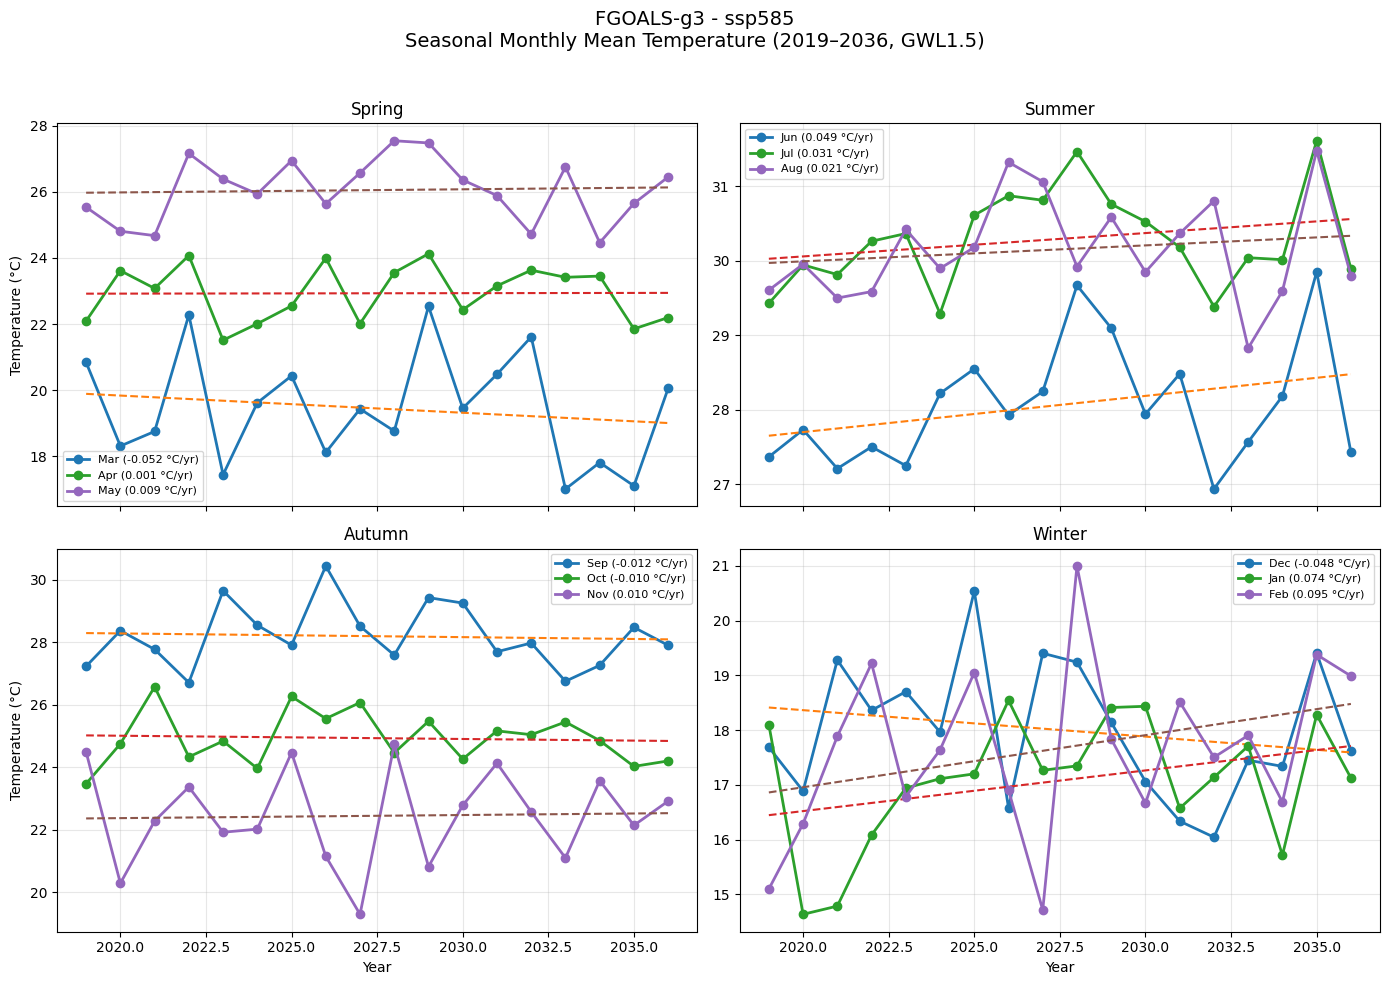

✅ Saved: /Users/stevechiao/AR6_統計降尺度_日資料_臺北市_平均溫/final_FGOALS-g3_seasonal/FGOALS-g3_ssp585_seasonal.png


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 設定
# =========================
model = "FGOALS-g3"
ssps = ["ssp245", "ssp370", "ssp585"]

start_year = 2019
end_year = 2036

season_def = {
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
    "Winter": [12, 1, 2]
}

month_labels = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
    7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}

save_dir = base_dir / "final_FGOALS-g3_seasonal"
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 日資料 → 月平均
# =========================
def daily_to_monthly(df):
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    monthly = (
        df.groupby(["year", "month"])["value"]
        .mean()
        .reset_index()
    )

    monthly = monthly[
        (monthly["year"] >= start_year) &
        (monthly["year"] <= end_year)
    ].copy()

    return monthly

# =========================
# 主程式
# =========================
for ssp in ssps:

    print(f"Processing {model} - {ssp}")

    df = build_series("GWL1.5", model, ssp)

    if df is None or len(df) == 0:
        print(f"⚠️ {model} - {ssp}: No data")
        continue

    monthly = daily_to_monthly(df)

    if monthly is None or len(monthly) == 0:
        print(f"⚠️ {model} - {ssp}: No monthly data")
        continue

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    axes = axes.flatten()

    for ax, (season, months) in zip(axes, season_def.items()):
        has_data = False

        for m in months:
            sub = monthly[monthly["month"] == m].copy()

            if len(sub) < 2:
                continue

            x = sub["year"].values
            y = sub["value"].values

            slope, intercept = np.polyfit(x, y, 1)
            trend = slope * x + intercept

            label = f"{month_labels[m]} ({slope:.3f} °C/yr)"

            ax.plot(
                x, y,
                marker="o",
                linewidth=2,
                label=label
            )

            ax.plot(
                x, trend,
                linestyle="--",
                linewidth=1.5
            )

            has_data = True

        ax.set_title(season, fontsize=12)
        ax.grid(alpha=0.3)

        if has_data:
            ax.legend(fontsize=8)
        else:
            ax.text(
                0.5, 0.5, "No data",
                transform=ax.transAxes,
                ha="center", va="center",
                color="gray"
            )

    axes[2].set_xlabel("Year")
    axes[3].set_xlabel("Year")
    axes[0].set_ylabel("Temperature (°C)")
    axes[2].set_ylabel("Temperature (°C)")

    fig.suptitle(
        f"{model} - {ssp}\nSeasonal Monthly Mean Temperature (2019–2036, GWL1.5)",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    out_path = save_dir / f"{model}_{ssp}_seasonal.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"✅ Saved: {out_path}")